# 🏗️ Construction Cost Prediction — Japan
## Country-Specific ML Regression Pipeline

**Target:** `construction_cost_per_m2_usd`

**Country:** Japan only (filtered from training data)

**Why split?** The combined model's RMSE (~171) mixes Japan ($1,400–2,600) and Philippines ($100–460) scales, producing misleading metrics. This notebook trains on Japan data only for honest, usable error metrics.

**Models:** Ridge, Lasso, ElasticNet, SVR, RandomForest, GradientBoosting, XGBoost

In [1]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================
import os
import warnings
import time
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    KFold, cross_val_score, cross_val_predict,
    RandomizedSearchCV, learning_curve, validation_curve
)
from sklearn.preprocessing import (
    StandardScaler, OrdinalEncoder, OneHotEncoder, TargetEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor
)
from xgboost import XGBRegressor
import joblib
from scipy import stats
from scipy.stats import uniform, randint, loguniform

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150
RANDOM_STATE = 42
CV_FOLDS = 5
N_ITER = 30
COUNTRY = 'Japan'
PLOTS_DIR = 'plots_japan'
MODELS_DIR = 'saved_models_japan'
TARGET = 'construction_cost_per_m2_usd'

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Detect GPU
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    HAS_GPU = result.returncode == 0
    if HAS_GPU:
        for line in result.stdout.split('\n'):
            if 'NVIDIA' in line and 'Driver' not in line:
                print(f"✅ GPU detected: {line.strip()}")
                break
        print("✅ CUDA will be used for XGBoost")
except FileNotFoundError:
    HAS_GPU = False

if not HAS_GPU:
    print("⚠️ No GPU detected — all models will run on CPU")

print(f"\n📋 Country: {COUNTRY}")
print(f"📋 Configuration: CV_FOLDS={CV_FOLDS}, N_ITER={N_ITER}, RANDOM_STATE={RANDOM_STATE}")
print(f"📁 Plots → {PLOTS_DIR}/  |  Models → {MODELS_DIR}/")

✅ GPU detected: |   0  NVIDIA GeForce RTX 3050 ...    On  |   00000000:01:00.0 Off |                  N/A |
✅ CUDA will be used for XGBoost

📋 Country: Japan
📋 Configuration: CV_FOLDS=5, N_ITER=30, RANDOM_STATE=42
📁 Plots → plots_japan/  |  Models → saved_models_japan/


## Phase 1: Data Loading & EDA

In [2]:
# ============================================================
# LOAD DATA & FILTER TO JAPAN
# ============================================================
df_full = pd.read_csv('train_tabular.csv')
df = df_full[df_full['country'] == COUNTRY].copy()
print(f"Full dataset: {df_full.shape[0]} rows")
print(f"{COUNTRY} subset: {df.shape[0]} rows ({df.shape[0]/df_full.shape[0]*100:.1f}%)")

# Drop useless + constant columns
DROP_COLS = ['data_id', 'sentinel2_tiff_file_name', 'viirs_tiff_file_name',
             'country', 'developed_country', 'region_economic_classification', 'landlocked']
df = df.drop(columns=DROP_COLS)
print(f"\nDropped {len(DROP_COLS)} constant/useless columns: {DROP_COLS}")
print(f"Remaining columns ({len(df.columns)}): {list(df.columns)}")

Full dataset: 1024 rows
Japan subset: 567 rows (55.4%)

Dropped 7 constant/useless columns: ['data_id', 'sentinel2_tiff_file_name', 'viirs_tiff_file_name', 'country', 'developed_country', 'region_economic_classification', 'landlocked']
Remaining columns (16): ['geolocation_name', 'quarter_label', 'year', 'deflated_gdp_usd', 'us_cpi', 'access_to_airport', 'access_to_port', 'access_to_highway', 'access_to_railway', 'straight_distance_to_capital_km', 'seismic_hazard_zone', 'flood_risk_class', 'tropical_cyclone_wind_risk', 'tornadoes_wind_risk', 'koppen_climate_zone', 'construction_cost_per_m2_usd']


In [3]:
# ============================================================
# INSPECT DATA
# ============================================================
print(f"Shape: {df.shape}")
print(f"\nDuplicates: {df.duplicated().sum()}")
print(f"\n--- Missing Values ---")
print(df.isnull().sum())
print(f"\n--- Data Types ---")
print(df.dtypes)
df.head()

Shape: (567, 16)

Duplicates: 0

--- Missing Values ---
geolocation_name                   0
quarter_label                      0
year                               0
deflated_gdp_usd                   0
us_cpi                             0
access_to_airport                  0
access_to_port                     0
access_to_highway                  0
access_to_railway                  0
straight_distance_to_capital_km    0
seismic_hazard_zone                0
flood_risk_class                   0
tropical_cyclone_wind_risk         4
tornadoes_wind_risk                0
koppen_climate_zone                0
construction_cost_per_m2_usd       0
dtype: int64

--- Data Types ---
geolocation_name                       str
quarter_label                          str
year                                 int64
deflated_gdp_usd                   float64
us_cpi                             float64
access_to_airport                      str
access_to_port                         str
access_to_highway 

,geolocation_name,quarter_label,year,deflated_gdp_usd,us_cpi,access_to_airport,access_to_port,access_to_highway,access_to_railway,straight_distance_to_capital_km,seismic_hazard_zone,flood_risk_class,tropical_cyclone_wind_risk,tornadoes_wind_risk,koppen_climate_zone,construction_cost_per_m2_usd
1,29000 Nara,2024-Q2,2024,3.928801e+12,143.968241,No,No,Yes,Yes,370.0,Moderate,Yes,Low,Very Low,Cfa,1567.878774
2,05000 Akita,2020-Q1,2020,4.069008e+12,118.435291,Yes,Yes,Yes,Yes,450.0,Moderate,Yes,Low,Very Low,Dfa,2009.827701
6,17000 Ishikawa,2021-Q2,2021,4.247589e+12,123.507547,Yes,Yes,Yes,Yes,270.0,Moderate,Yes,Moderate,Low,Cfa,1760.371729
7,22000 Shizuoka,2021-Q3,2021,4.247589e+12,125.484873,Yes,Yes,Yes,Yes,150.0,High,Yes,Moderate,Low,Cfa,1998.151428
8,21000 Gifu,2020-Q2,2020,4.069008e+12,117.795699,No,No,Yes,Yes,270.0,Moderate,Yes,Low,Low,Cfa,2038.472107


In [4]:
df.describe()

,year,deflated_gdp_usd,us_cpi,straight_distance_to_capital_km,construction_cost_per_m2_usd
count,567.000000,5.670000e+02,567.000000,567.000000,567.000000
mean,2021.421517,4.032764e+12,129.302603,452.425044,1830.268632
std,1.751454,1.163826e+11,10.504781,340.435644,309.108275
min,2019.000000,3.880440e+12,115.978119,0.000000,1191.698232
25%,2020.000000,3.928801e+12,118.435291,250.000000,1630.923139
50%,2021.000000,4.069008e+12,127.389434,370.000000,1776.895274
75%,2023.000000,4.070265e+12,139.505615,650.000000,1957.640801
max,2024.000000,4.247589e+12,144.727986,1550.000000,3628.201594


In [5]:
# ============================================================
# CHECK FOR NEAR-CONSTANT COLUMNS (auto-detect & drop)
# ============================================================
near_constant = []
for col in df.columns:
    if col == TARGET:
        continue
    nunique = df[col].nunique()
    if nunique <= 1:
        near_constant.append(col)
        print(f"  ⚠️ {col}: {nunique} unique value(s) → DROPPING")

if near_constant:
    df = df.drop(columns=near_constant)
    print(f"\n✅ Dropped {len(near_constant)} constant columns: {near_constant}")
else:
    print("✅ No additional constant columns found")

print(f"\nFinal columns ({len(df.columns)}): {list(df.columns)}")

  ⚠️ access_to_highway: 1 unique value(s) → DROPPING

✅ Dropped 1 constant columns: ['access_to_highway']

Final columns (15): ['geolocation_name', 'quarter_label', 'year', 'deflated_gdp_usd', 'us_cpi', 'access_to_airport', 'access_to_port', 'access_to_railway', 'straight_distance_to_capital_km', 'seismic_hazard_zone', 'flood_risk_class', 'tropical_cyclone_wind_risk', 'tornadoes_wind_risk', 'koppen_climate_zone', 'construction_cost_per_m2_usd']


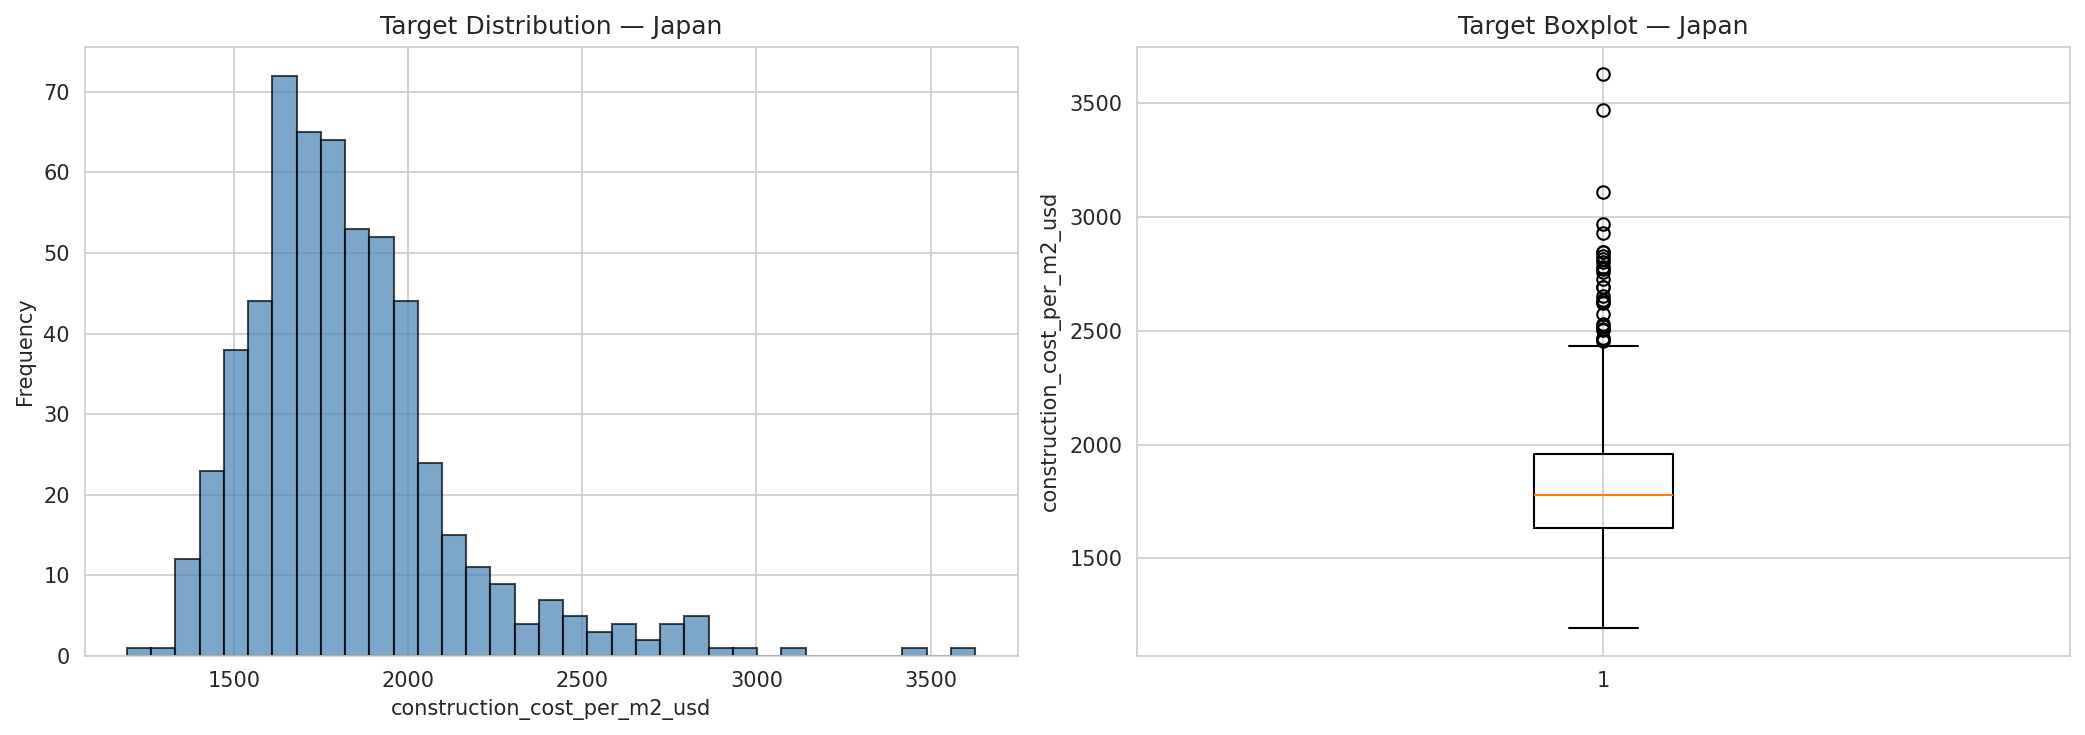


Target stats:
count     567.000000
mean     1830.268632
std       309.108275
min      1191.698232
25%      1630.923139
50%      1776.895274
75%      1957.640801
max      3628.201594
Name: construction_cost_per_m2_usd, dtype: float64

Skewness: 1.668
Kurtosis: 4.758


In [6]:
# ============================================================
# EDA: TARGET DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[TARGET], bins=35, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title(f'Target Distribution — {COUNTRY}')
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df[TARGET], vert=True)
axes[1].set_title(f'Target Boxplot — {COUNTRY}')
axes[1].set_ylabel(TARGET)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/eda_01_target_distribution.png', bbox_inches='tight')
plt.show()

print(f"\nTarget stats:\n{df[TARGET].describe()}")
print(f"\nSkewness: {df[TARGET].skew():.3f}")
print(f"Kurtosis: {df[TARGET].kurtosis():.3f}")

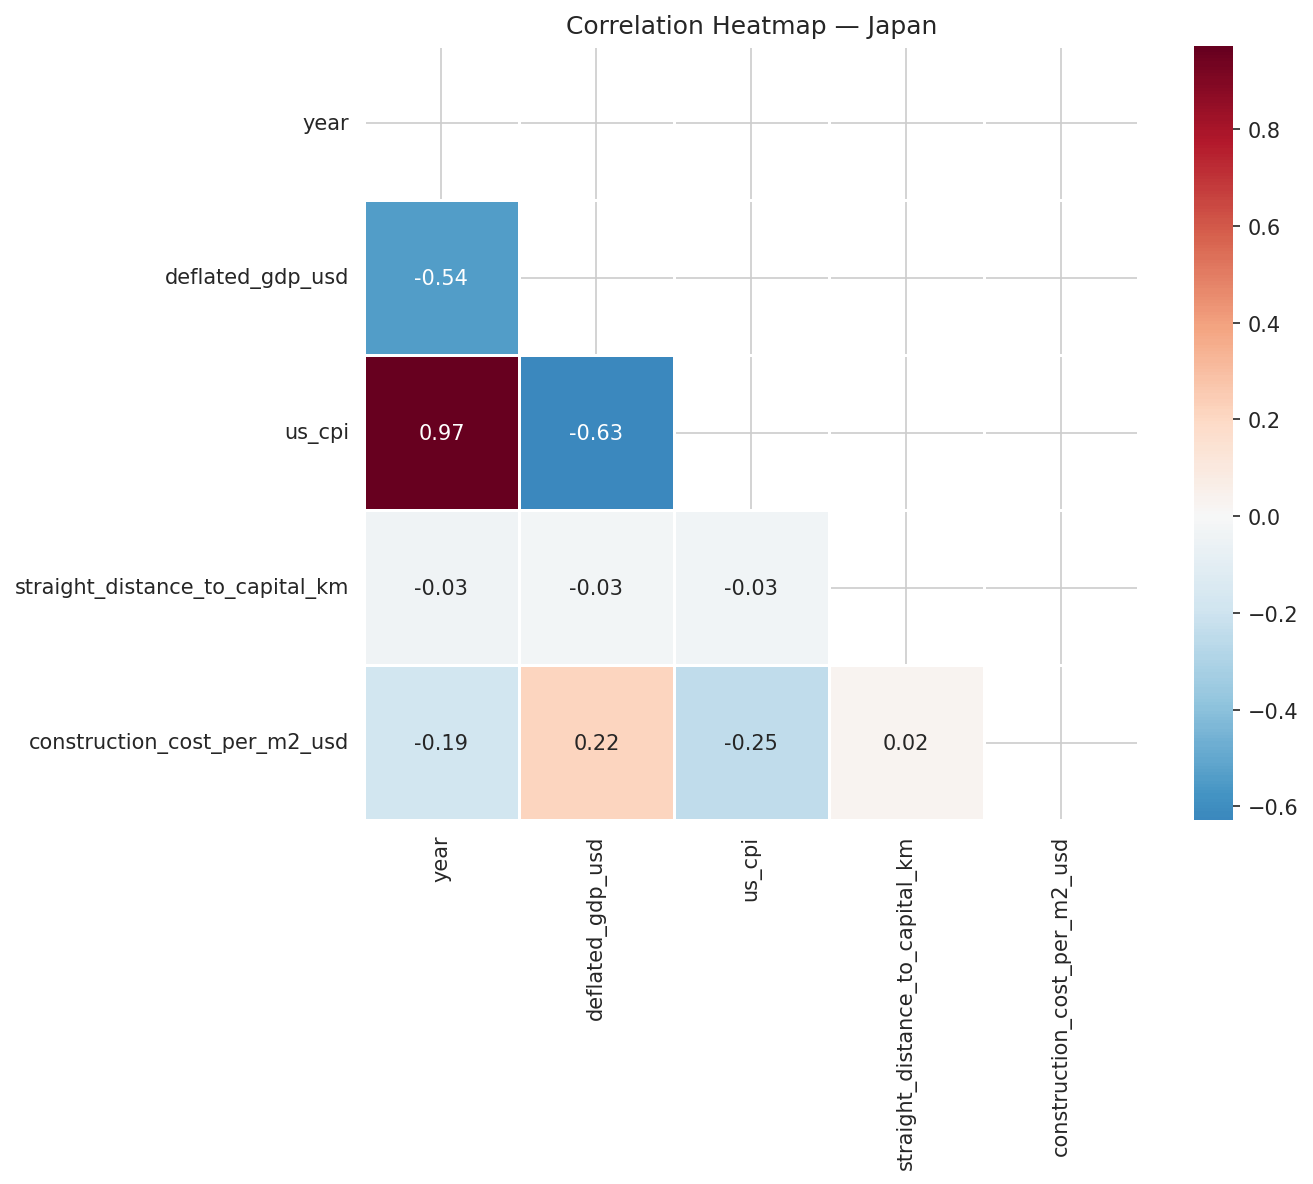

In [7]:
# ============================================================
# EDA: CORRELATION HEATMAP
# ============================================================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title(f'Correlation Heatmap — {COUNTRY}')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/eda_02_correlation_heatmap.png', bbox_inches='tight')
plt.show()

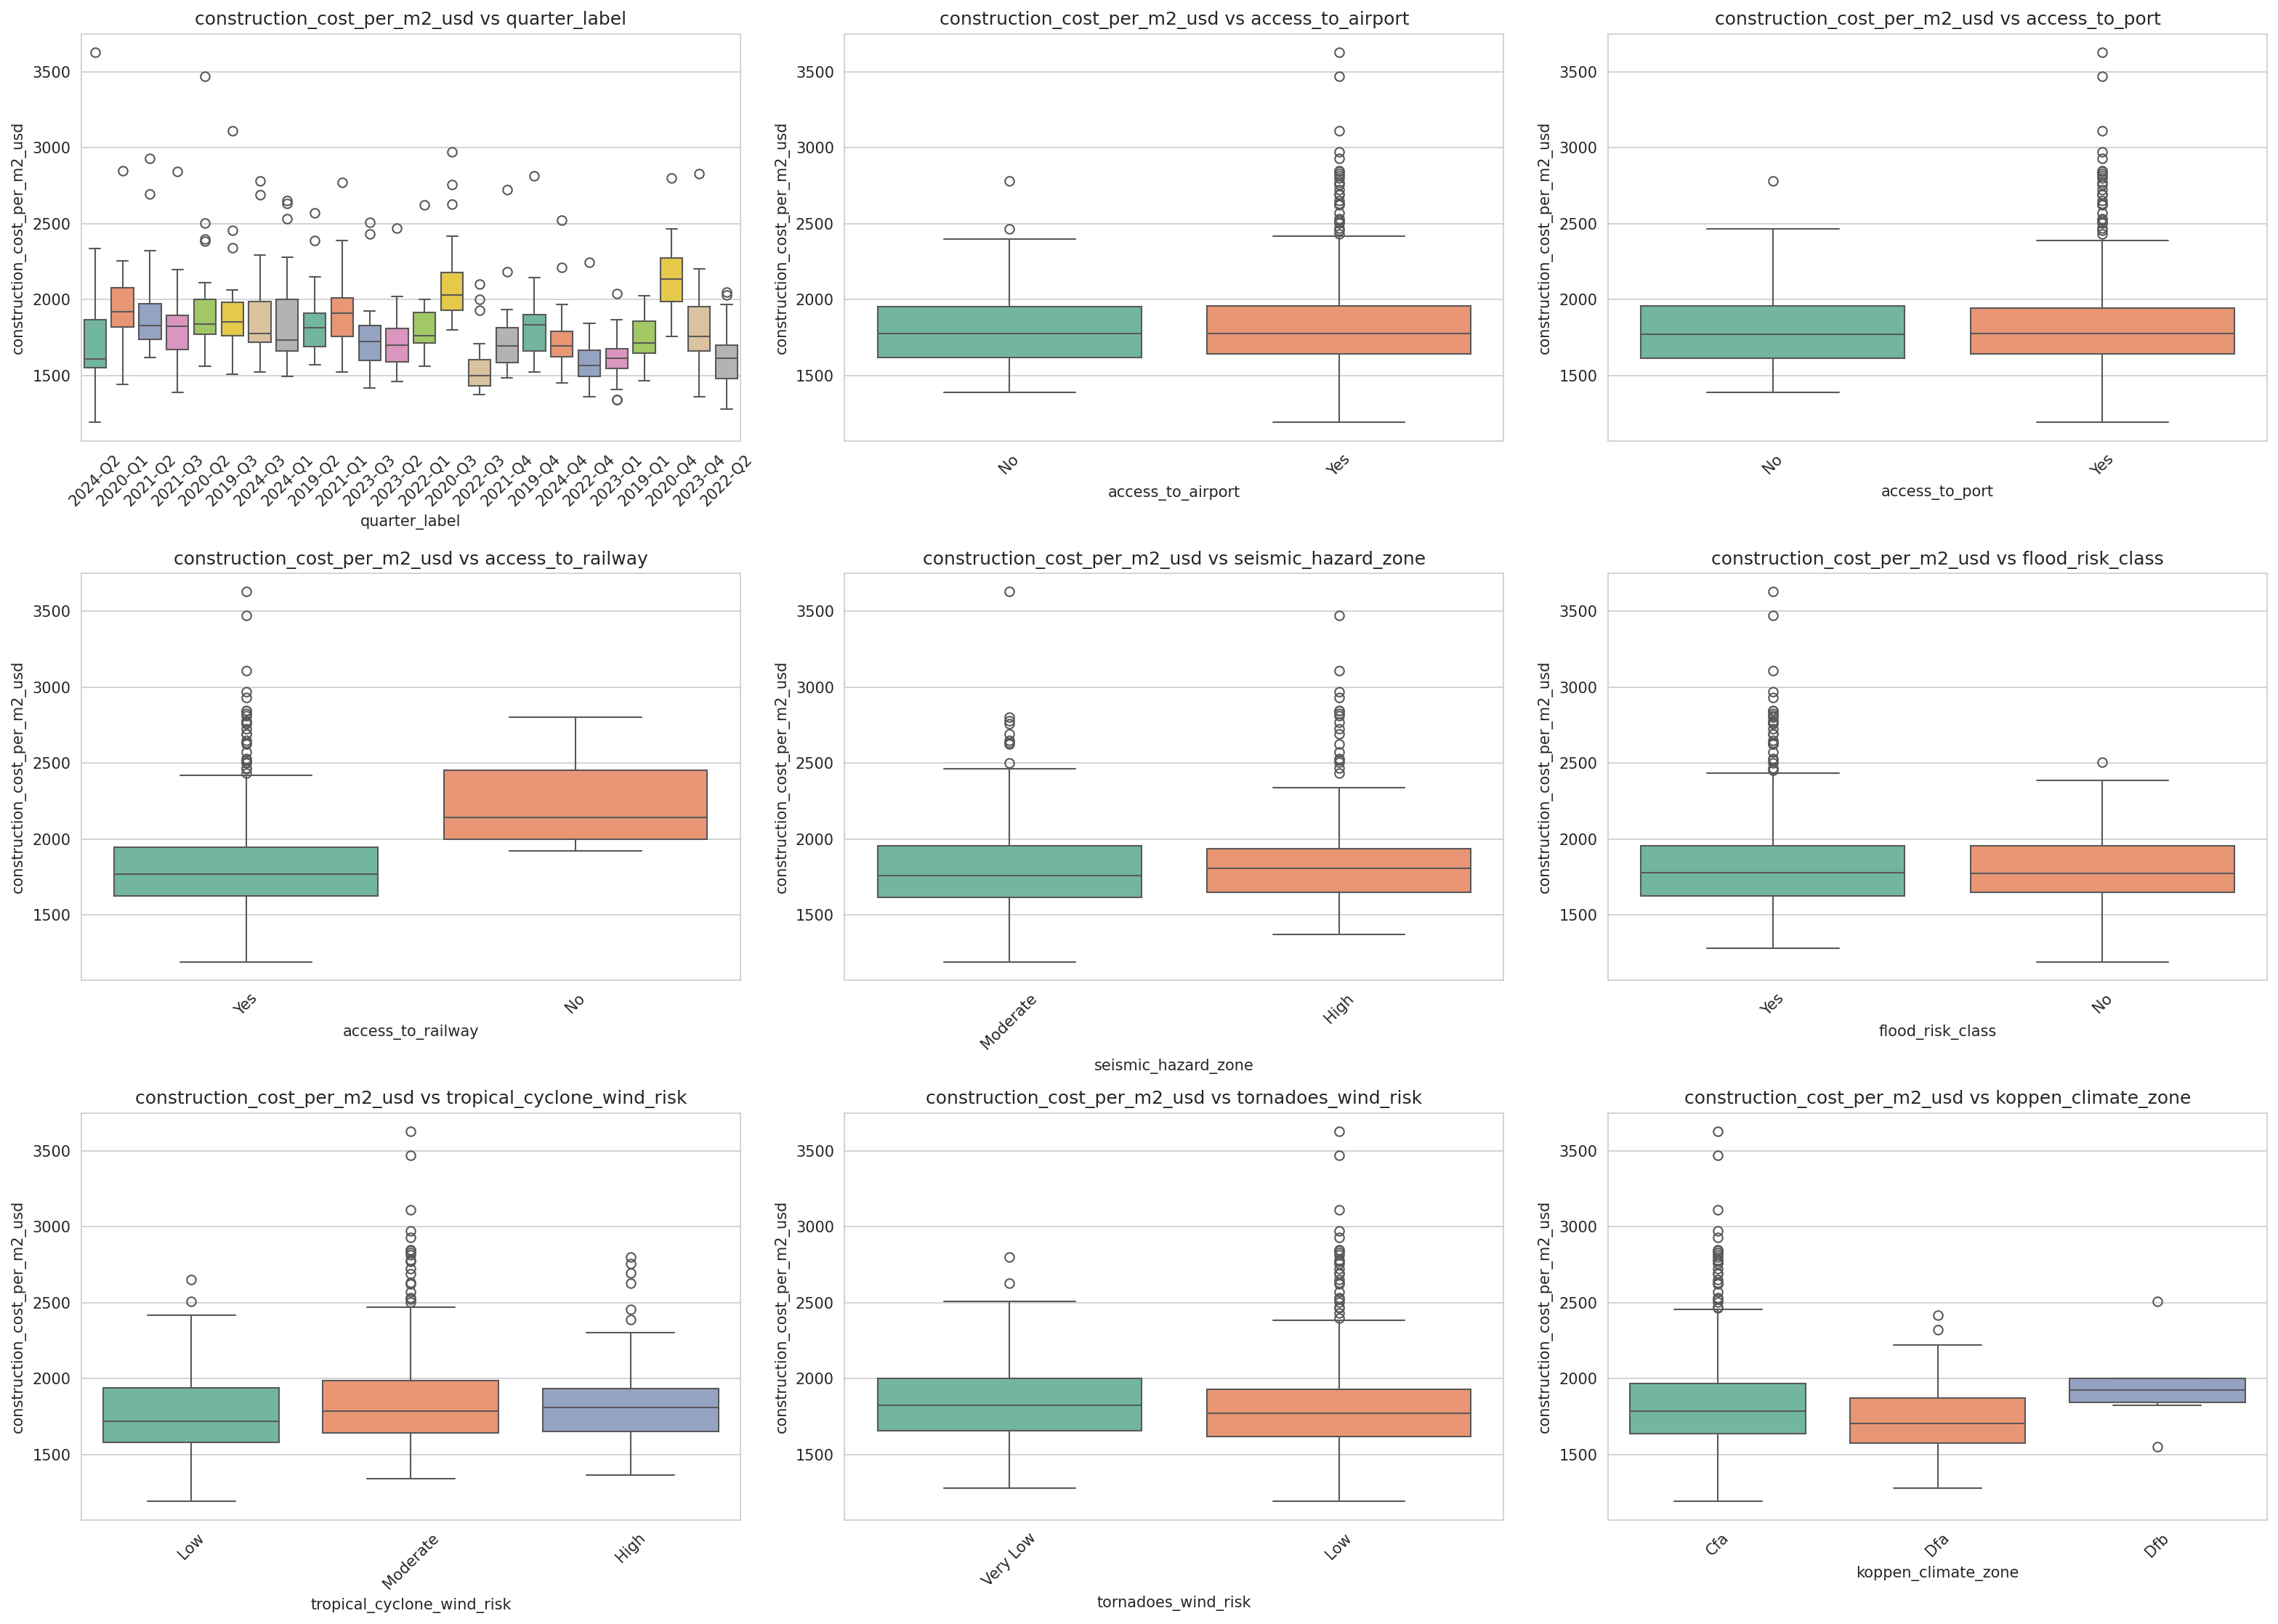

In [8]:
# ============================================================
# EDA: TARGET vs CATEGORICALS
# ============================================================
cat_cols_for_eda = [c for c in df.select_dtypes(include='object').columns if c != 'geolocation_name']

n_cats = len(cat_cols_for_eda)
if n_cats > 0:
    ncols = min(3, n_cats)
    nrows = (n_cats + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for i, col in enumerate(cat_cols_for_eda):
        sns.boxplot(data=df, x=col, y=TARGET, ax=axes[i], palette='Set2')
        axes[i].set_title(f'{TARGET} vs {col}')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/eda_03_target_vs_categoricals.png', bbox_inches='tight')
    plt.show()
else:
    print("No categorical columns for EDA plots")

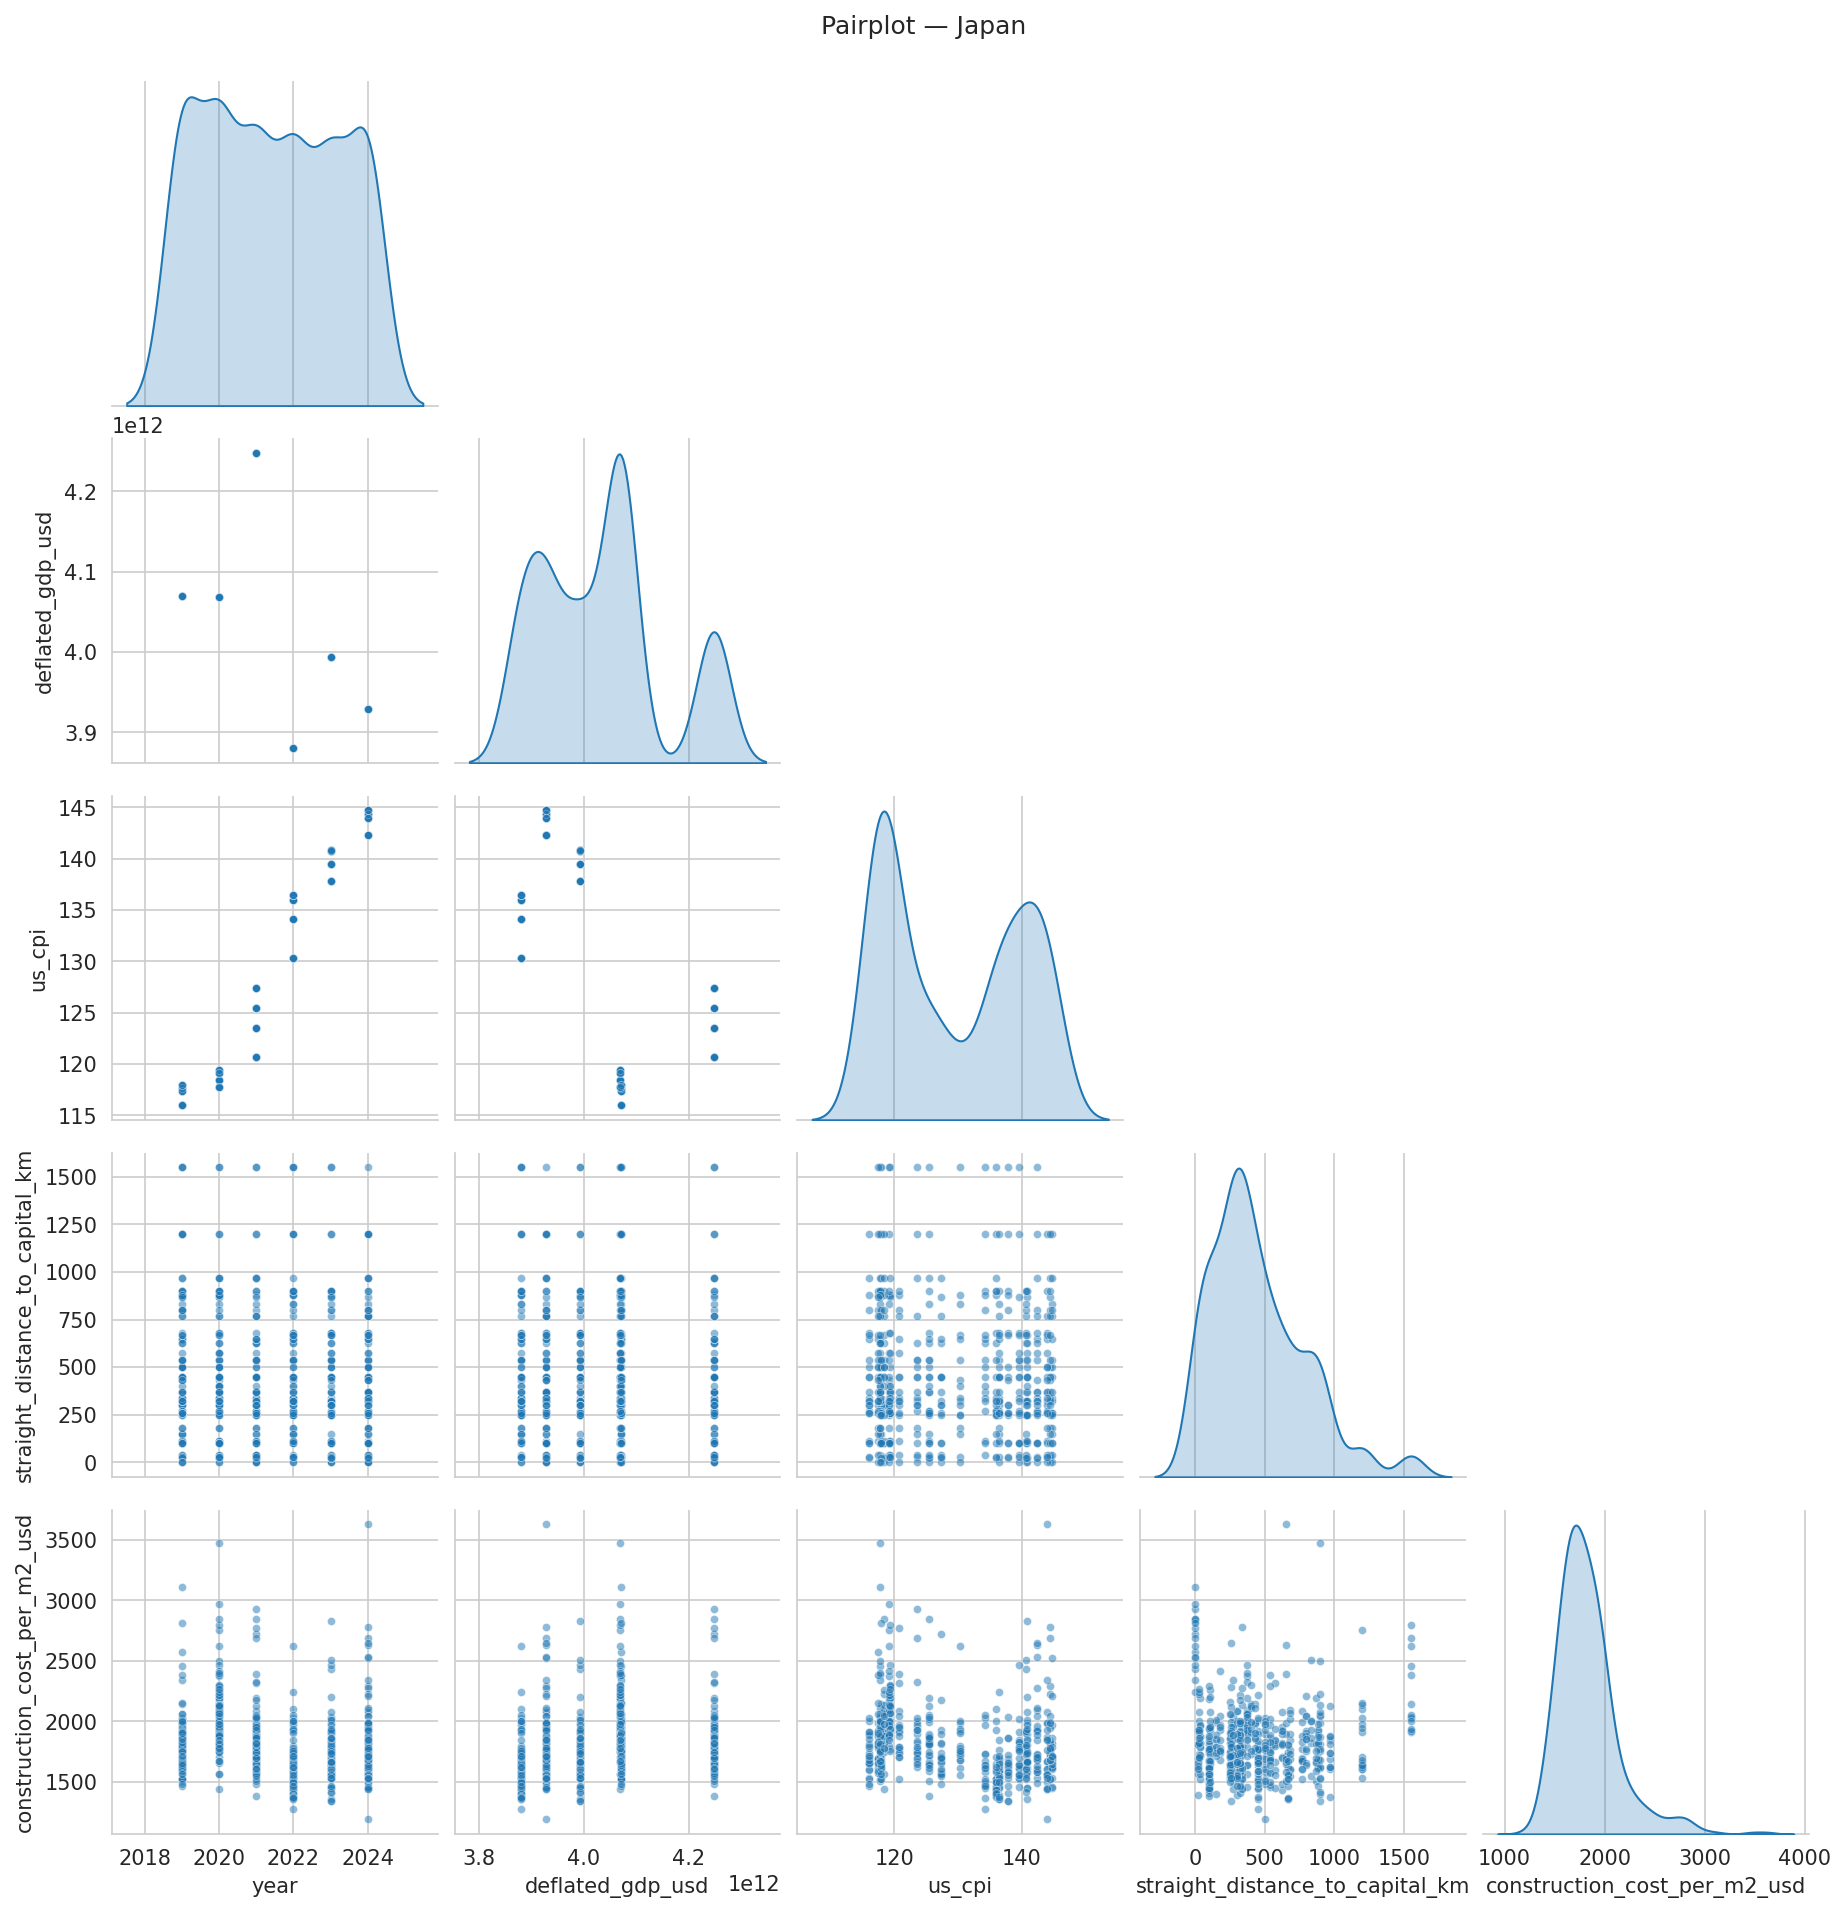

In [9]:
# ============================================================
# EDA: PAIRPLOT — NUMERICAL FEATURES
# ============================================================
num_features = [c for c in df.select_dtypes(include=[np.number]).columns if c != TARGET]
plot_cols = num_features + [TARGET]

g = sns.pairplot(df[plot_cols], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15}, corner=True)
g.figure.suptitle(f'Pairplot — {COUNTRY}', y=1.02)
plt.savefig(f'{PLOTS_DIR}/eda_04_pairplot_numerical.png', bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# EDA: VALUE COUNTS
# ============================================================
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"{col} (unique={df[col].nunique()})")
    print('='*50)
    print(df[col].value_counts().head(15))


geolocation_name (unique=47)
geolocation_name
18000 Fukui        19
13000 Tokyo        18
42000 Nagasaki     17
16000 Toyama       17
25000 Shiga        17
14000 Kanagawa     16
26000 Kyoto        15
06000 Yamagata     14
12000 Chiba        14
24000 Mie          14
09000 Tochigi      14
08000 Ibaraki      14
03000 Iwate        13
19000 Yamanashi    13
15000 Niigata      13
Name: count, dtype: int64

quarter_label (unique=24)
quarter_label
2020-Q3    30
2021-Q3    29
2019-Q3    28
2022-Q4    28
2024-Q1    27
2019-Q2    27
2019-Q4    27
2024-Q2    26
2020-Q2    25
2019-Q1    25
2020-Q1    24
2024-Q3    24
2022-Q3    24
2023-Q2    23
2023-Q4    23
Name: count, dtype: int64

access_to_airport (unique=2)
access_to_airport
Yes    434
No     133
Name: count, dtype: int64

access_to_port (unique=2)
access_to_port
Yes    436
No     131
Name: count, dtype: int64

access_to_railway (unique=2)
access_to_railway
Yes    558
No       9
Name: count, dtype: int64

seismic_hazard_zone (unique=2)
seismi

## Phase 1.5: Feature Engineering

In [11]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
df['quarter'] = df['quarter_label'].str.extract(r'Q(\d)').astype(int)
df = df.drop(columns=['quarter_label'])

print(f"✅ Created 'quarter' column (values: {sorted(df['quarter'].unique())})")
print(f"✅ Dropped 'quarter_label'")
print(f"\nFinal columns ({len(df.columns)}): {list(df.columns)}")
print(f"Shape: {df.shape}")

✅ Created 'quarter' column (values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)])
✅ Dropped 'quarter_label'

Final columns (15): ['geolocation_name', 'year', 'deflated_gdp_usd', 'us_cpi', 'access_to_airport', 'access_to_port', 'access_to_railway', 'straight_distance_to_capital_km', 'seismic_hazard_zone', 'flood_risk_class', 'tropical_cyclone_wind_risk', 'tornadoes_wind_risk', 'koppen_climate_zone', 'construction_cost_per_m2_usd', 'quarter']
Shape: (567, 15)


## Phase 2: Preprocessing Pipeline

In [12]:
# ============================================================
# DEFINE COLUMN GROUPS & PREPROCESSING PIPELINE
# ============================================================
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Auto-detect column groups from remaining data
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

object_cols = X.select_dtypes(include='object').columns.tolist()
binary_cols = [c for c in object_cols if set(X[c].unique()).issubset({'Yes', 'No'})]
high_card_cols = [c for c in object_cols if X[c].nunique() > 10]
low_card_cat_cols = [c for c in object_cols if c not in binary_cols and c not in high_card_cols]

print(f"Numerical ({len(numerical_cols)}):        {numerical_cols}")
print(f"Binary ({len(binary_cols)}):           {binary_cols}")
print(f"Low-card categorical ({len(low_card_cat_cols)}): {low_card_cat_cols}")
print(f"High-card categorical ({len(high_card_cols)}): {high_card_cols}")
print(f"\nTotal features: {X.shape[1]}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Build ColumnTransformer
transformers = [('num', StandardScaler(), numerical_cols)]

if binary_cols:
    transformers.append(
        ('bin', OrdinalEncoder(categories=[['No', 'Yes']] * len(binary_cols)), binary_cols)
    )
if low_card_cat_cols:
    transformers.append(
        ('cat_low', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist',
                                   sparse_output=False), low_card_cat_cols)
    )
if high_card_cols:
    transformers.append(
        ('cat_high', TargetEncoder(random_state=RANDOM_STATE), high_card_cols)
    )

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder='drop',
    verbose_feature_names_out=True
)

print("\n✅ ColumnTransformer built successfully")

Numerical (5):        ['year', 'deflated_gdp_usd', 'us_cpi', 'straight_distance_to_capital_km', 'quarter']
Binary (4):           ['access_to_airport', 'access_to_port', 'access_to_railway', 'flood_risk_class']
Low-card categorical (4): ['seismic_hazard_zone', 'tropical_cyclone_wind_risk', 'tornadoes_wind_risk', 'koppen_climate_zone']
High-card categorical (1): ['geolocation_name']

Total features: 14
X shape: (567, 14), y shape: (567,)

✅ ColumnTransformer built successfully


## Phase 3: Model Training & Hyperparameter Tuning

In [13]:
# ============================================================
# DEFINE MODELS & HYPERPARAMETER SEARCH SPACES (WITH LOG TRANSFORMATION)
# ============================================================
import numpy as np
from sklearn.compose import TransformedTargetRegressor

xgb_device = {'device': 'cuda'} if HAS_GPU else {}

# We are wrapping the top 3 models in TransformedTargetRegressor. 
# It applies np.log1p before training and np.expm1 during prediction.
# Note the 'model__regressor__' prefix required for hyperparameter searching nested objects.

models = {
    'XGBoost': {
        'model': TransformedTargetRegressor(
            regressor=XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, **xgb_device),
            func=np.log1p,       
            inverse_func=np.expm1
        ),
        'params': {
            'model__regressor__n_estimators': randint(100, 800),
            'model__regressor__max_depth': randint(3, 10),
            'model__regressor__learning_rate': loguniform(1e-3, 0.3),
            'model__regressor__subsample': uniform(0.6, 0.4),
            'model__regressor__colsample_bytree': uniform(0.5, 0.5),
        }
    },
    'RandomForest': {
        'model': TransformedTargetRegressor(
            regressor=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
            func=np.log1p,
            inverse_func=np.expm1
        ),
        'params': {
            'model__regressor__n_estimators': randint(100, 800),
            'model__regressor__max_depth': [None, 5, 10, 15],
            'model__regressor__min_samples_split': randint(2, 15),
            'model__regressor__min_samples_leaf': randint(1, 10),
        }
    },
    'GradientBoosting': {
        'model': TransformedTargetRegressor(
            regressor=GradientBoostingRegressor(random_state=RANDOM_STATE),
            func=np.log1p,
            inverse_func=np.expm1
        ),
        'params': {
            'model__regressor__n_estimators': randint(100, 800),
            'model__regressor__max_depth': randint(3, 10),
            'model__regressor__learning_rate': loguniform(1e-3, 0.3),
            'model__regressor__subsample': uniform(0.6, 0.4),
        }
    }
}
print(f"✅ {len(models)} log-transformed Top-3 Models defined:")
for name in models:
    n_params = len(models[name]['params'])
    print(f"   • {name} ({n_params} hyperparameters)")



✅ 3 log-transformed Top-3 Models defined:
   • XGBoost (5 hyperparameters)
   • RandomForest (4 hyperparameters)
   • GradientBoosting (4 hyperparameters)


In [14]:
# ============================================================
# TRAINING LOOP — RandomizedSearchCV for all models
# ============================================================
# RESUMABLE: re-run skips already-trained models.
# To retrain ALL: results, best_estimators, cv_detailed_results = {}, {}, {}

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

if 'results' not in dir() or not isinstance(results, dict):
    results = {}
if 'best_estimators' not in dir() or not isinstance(best_estimators, dict):
    best_estimators = {}
if 'cv_detailed_results' not in dir() or not isinstance(cv_detailed_results, dict):
    cv_detailed_results = {}

remaining = {k: v for k, v in models.items() if k not in best_estimators}
print(f"Training {len(remaining)}/{len(models)} models ({len(best_estimators)} already done)...")
if best_estimators:
    print(f"   ✅ Already trained: {list(best_estimators.keys())}")
print("=" * 80)

for name, config in remaining.items():
    start_time = time.time()
    print(f"\n🔄 Training: {name}...")

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', config['model'])
    ])

    search = RandomizedSearchCV(
        pipe,
        param_distributions=config['params'],
        n_iter=N_ITER,
        cv=kf,
        scoring='neg_mean_squared_error',
        random_state=RANDOM_STATE,
        n_jobs=-1 if name != 'XGBoost' else 1,
        return_train_score=True,
        verbose=0
    )

    search.fit(X, y)

    best_estimators[name] = search.best_estimator_
    elapsed = time.time() - start_time

    cv_preds = cross_val_predict(search.best_estimator_, X, y, cv=kf)

    rmse = np.sqrt(mean_squared_error(y, cv_preds))
    mae = mean_absolute_error(y, cv_preds)
    r2 = r2_score(y, cv_preds)

    fold_scores = cross_val_score(search.best_estimator_, X, y, cv=kf,
                                   scoring='neg_mean_squared_error')
    fold_rmses = np.sqrt(-fold_scores)

    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Best_Params': search.best_params_,
        'CV_Preds': cv_preds,
        'Fold_RMSEs': fold_rmses,
        'Time_s': elapsed,
        'Search_CV_Results': pd.DataFrame(search.cv_results_),
    }
    cv_detailed_results[name] = search.cv_results_

    print(f"   ✅ {name}: RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f} | Time={elapsed:.1f}s")
    print(f"      Best params: { {k.replace('model__', ''): v for k, v in search.best_params_.items()} }")

print("\n" + "=" * 80)
print(f"\n🎉 All {len(best_estimators)} models trained!")

Training 3/3 models (0 already done)...

🔄 Training: XGBoost...


   ✅ XGBoost: RMSE=215.4309 | MAE=145.0399 | R²=0.5134 | Time=497.4s
      Best params: {'regressor__colsample_bytree': np.float64(0.8091930046665436), 'regressor__learning_rate': np.float64(0.008859408511922198), 'regressor__max_depth': 6, 'regressor__n_estimators': 604, 'regressor__subsample': np.float64(0.6185801650879991)}

🔄 Training: RandomForest...


/home/ramcharan/ml/construction/new/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/ramcharan/ml/construction/new/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/ramcharan/ml/construction/new/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/ramcharan/

   ✅ RandomForest: RMSE=216.4419 | MAE=146.2375 | R²=0.5088 | Time=28.2s
      Best params: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 191}

🔄 Training: GradientBoosting...
   ✅ GradientBoosting: RMSE=217.6991 | MAE=145.0211 | R²=0.5031 | Time=12.4s
      Best params: {'regressor__learning_rate': np.float64(0.011189657849413852), 'regressor__max_depth': 3, 'regressor__n_estimators': 747, 'regressor__subsample': np.float64(0.602208846849441)}


🎉 All 3 models trained!


In [16]:
# ============================================================
# RESULTS COMPARISON TABLE
# ============================================================
results_df = pd.DataFrame({
    name: {
        'RMSE': r['RMSE'],
        'MAE': r['MAE'],
        'R²': r['R2'],
        'RMSE_std': r['Fold_RMSEs'].std(),
        'Time (s)': r['Time_s']
    }
    for name, r in results.items()
}).T.sort_values('RMSE')

results_df.index.name = 'Model'
print(f"\n📊 MODEL COMPARISON — {COUNTRY} (sorted by RMSE):\n")
results_df.style.highlight_min(subset=['RMSE', 'MAE'], color='lightgreen') \
                .highlight_max(subset=['R²'], color='lightgreen') \
                .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}',
                         'RMSE_std': '{:.4f}', 'Time (s)': '{:.1f}'})


📊 MODEL COMPARISON — Japan (sorted by RMSE):



AttributeError: The '.style' accessor requires jinja2

## Phase 4: Evaluation & Visualization

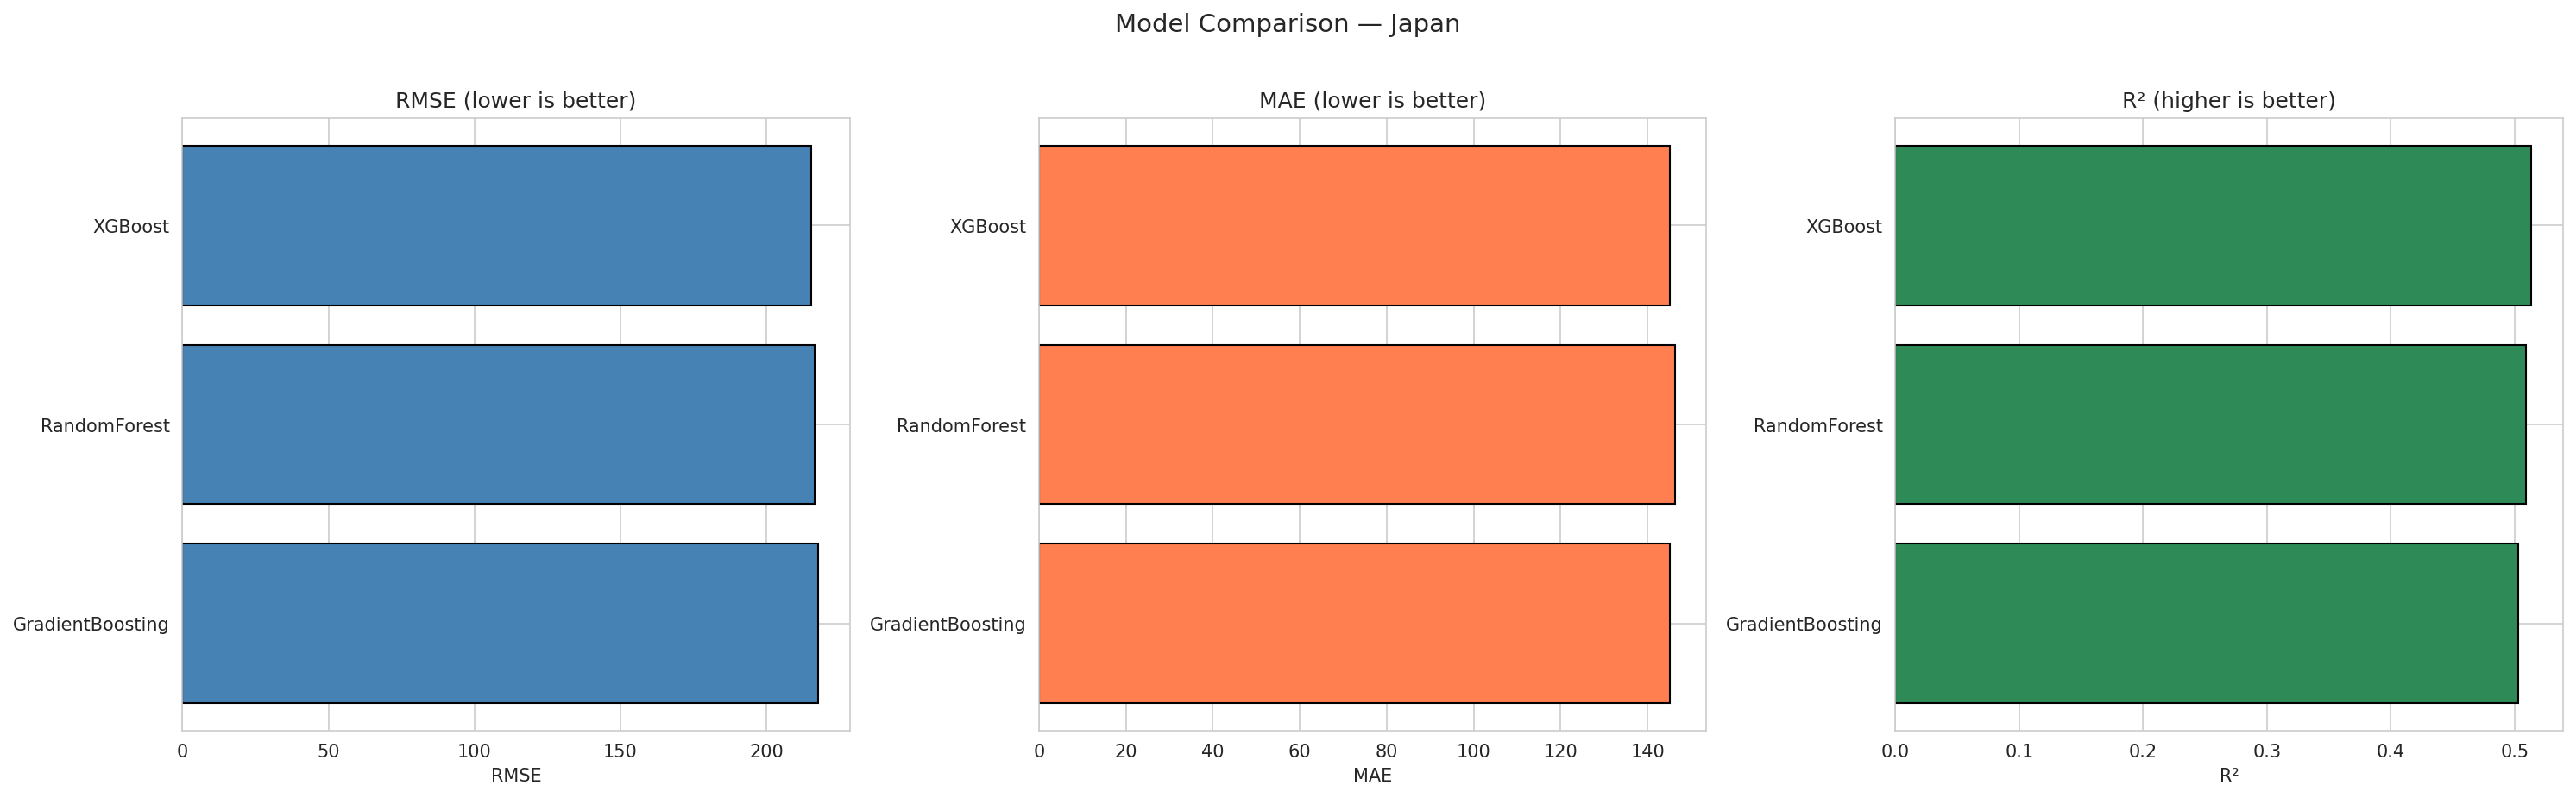

In [17]:
# ============================================================
# PLOT 1: MODEL COMPARISON METRICS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sorted_models = results_df.index.tolist()

axes[0].barh(sorted_models, results_df['RMSE'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('RMSE'); axes[0].set_title('RMSE (lower is better)'); axes[0].invert_yaxis()

axes[1].barh(sorted_models, results_df['MAE'], color='coral', edgecolor='black')
axes[1].set_xlabel('MAE'); axes[1].set_title('MAE (lower is better)'); axes[1].invert_yaxis()

axes[2].barh(sorted_models, results_df['R²'], color='seagreen', edgecolor='black')
axes[2].set_xlabel('R²'); axes[2].set_title('R² (higher is better)'); axes[2].invert_yaxis()

plt.suptitle(f'Model Comparison — {COUNTRY}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_model_comparison_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

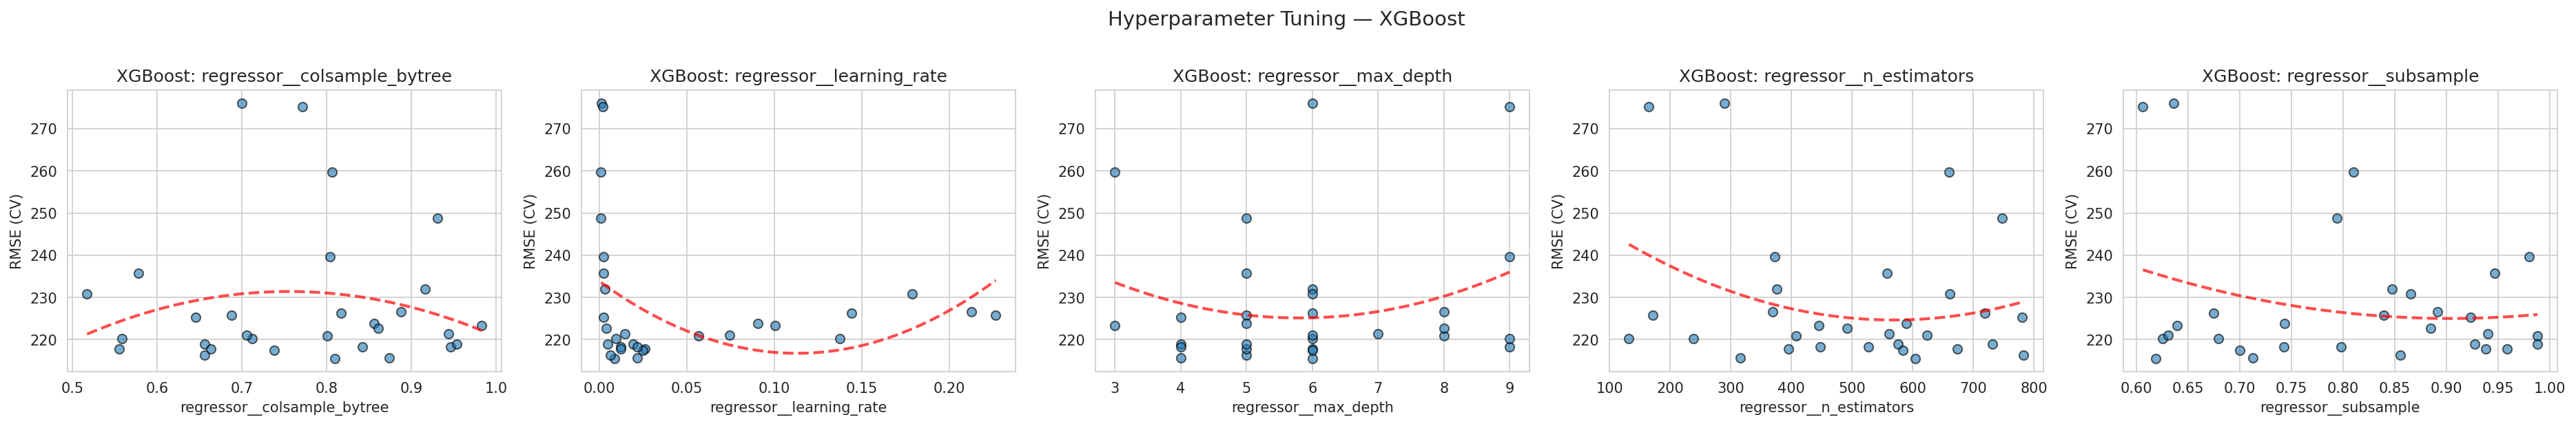

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


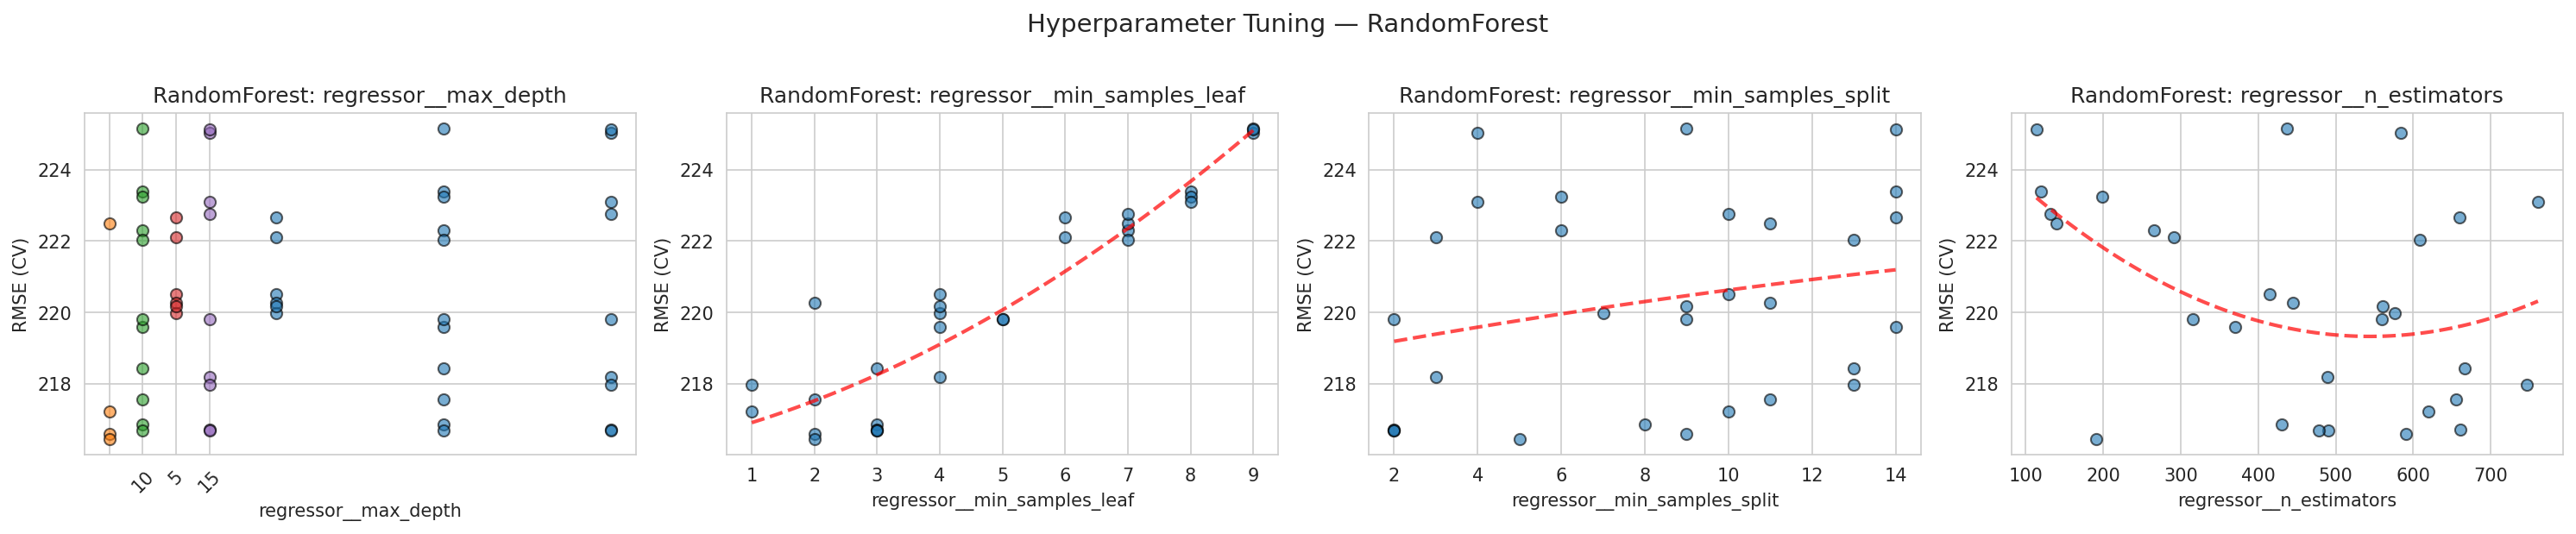

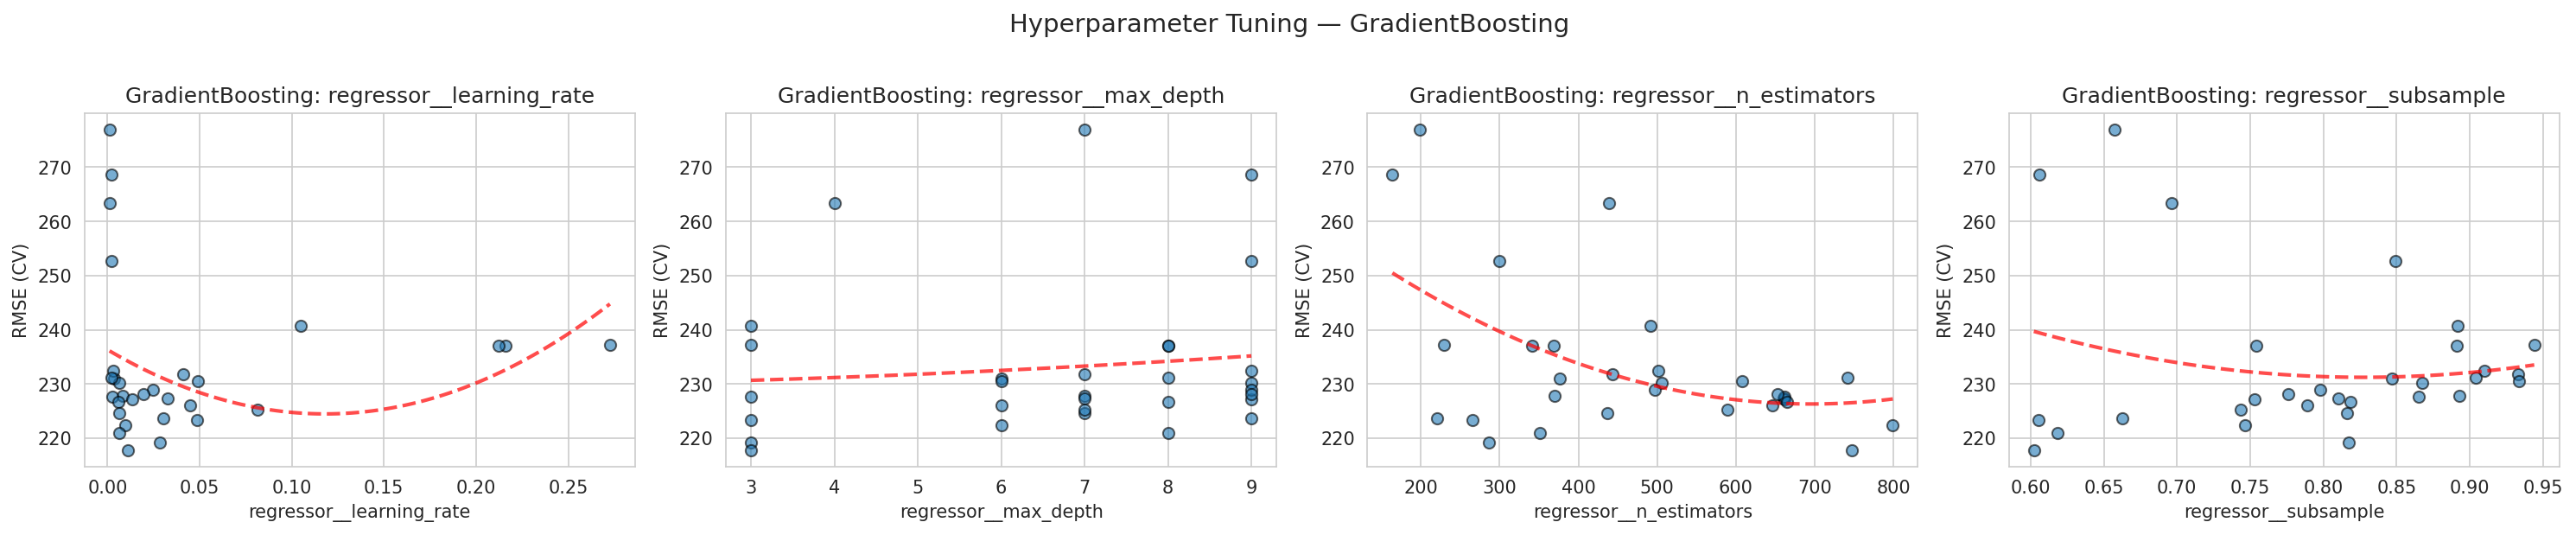

In [18]:
# ============================================================
# PLOT 2: HYPERPARAMETER TUNING CURVES
# ============================================================
for name, r in results.items():
    cv_res = r['Search_CV_Results']
    param_cols = [c for c in cv_res.columns if c.startswith('param_model__')]
    if not param_cols:
        continue

    n_params = len(param_cols)
    fig, axes = plt.subplots(1, n_params, figsize=(5 * n_params, 4))
    if n_params == 1:
        axes = [axes]

    for ax, param_col in zip(axes, param_cols):
        param_name = param_col.replace('param_model__', '')
        values = cv_res[param_col].values
        scores = np.sqrt(-cv_res['mean_test_score'].values)

        try:
            values_float = values.astype(float)
            ax.scatter(values_float, scores, alpha=0.6, edgecolors='black', s=40)
            z = np.polyfit(values_float, scores, 2)
            p = np.poly1d(z)
            x_line = np.linspace(values_float.min(), values_float.max(), 100)
            ax.plot(x_line, p(x_line), 'r--', alpha=0.7, linewidth=2)
        except (ValueError, TypeError):
            unique_vals = list(set(values))
            for j, val in enumerate(unique_vals):
                mask = values == val
                ax.scatter([j] * mask.sum(), scores[mask], alpha=0.6, edgecolors='black', s=40)
            ax.set_xticks(range(len(unique_vals)))
            ax.set_xticklabels(unique_vals, rotation=45)

        ax.set_xlabel(param_name); ax.set_ylabel('RMSE (CV)')
        ax.set_title(f'{name}: {param_name}')

    plt.suptitle(f'Hyperparameter Tuning — {name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/02_hyperparam_{name}.png', bbox_inches='tight', dpi=150)
    plt.show()

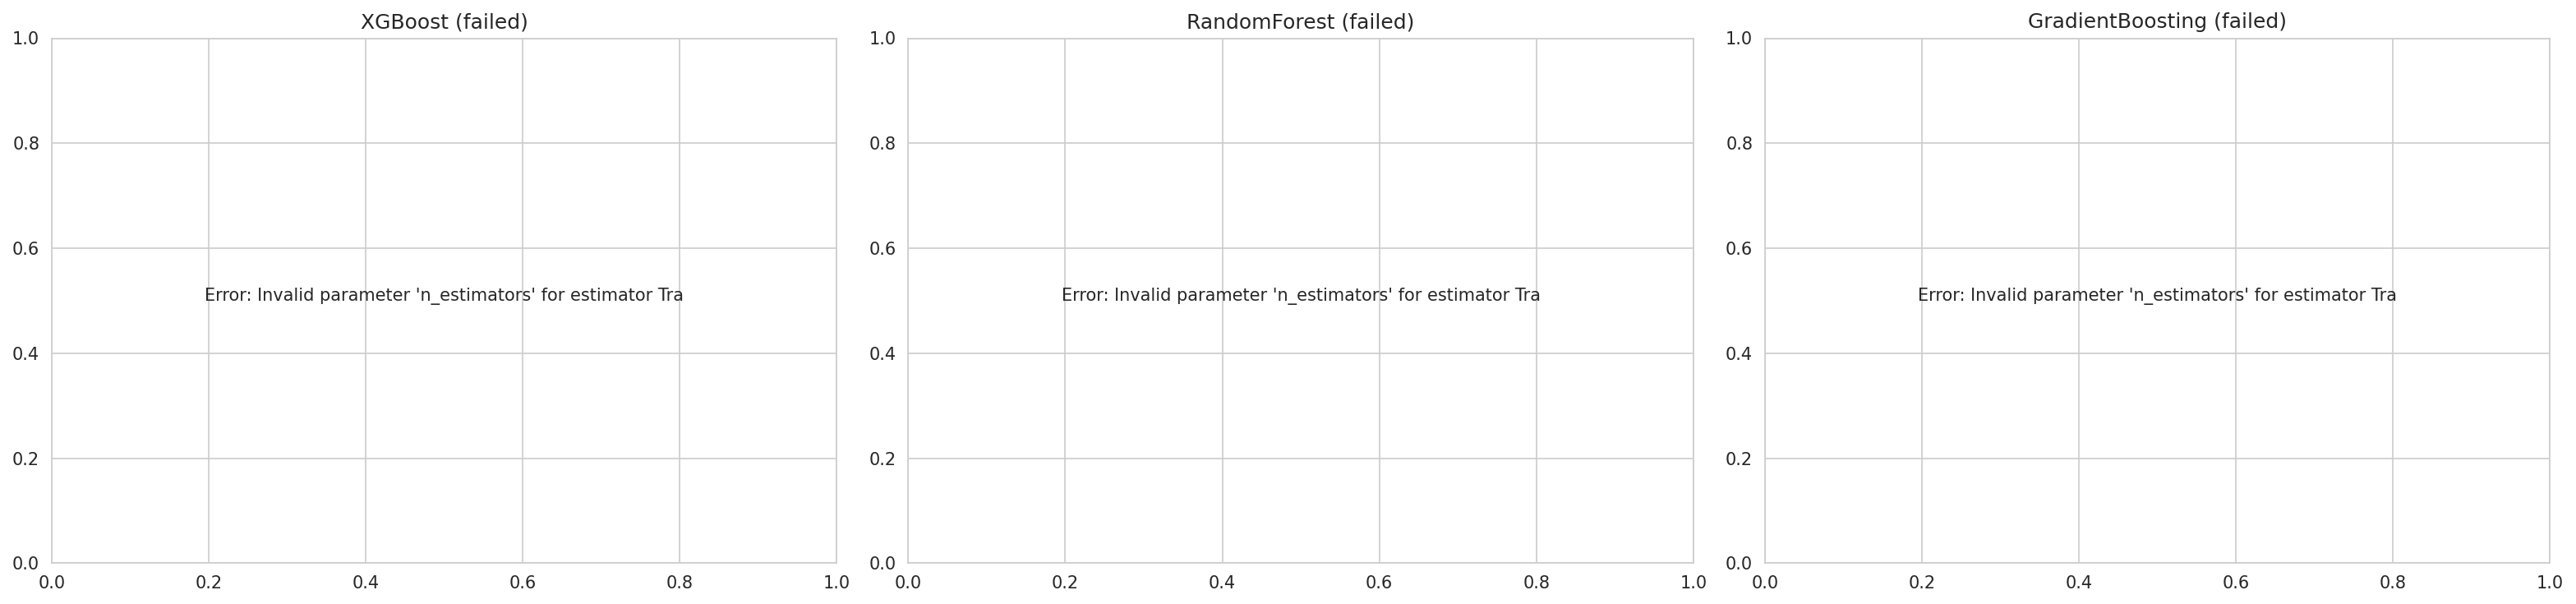

In [19]:
# ============================================================
# PLOT 3: VALIDATION CURVES (Top 3 Models)
# ============================================================
top3 = results_df.index[:3].tolist()

validation_param_map = {
    'Ridge': ('model__alpha', np.logspace(-3, 3, 20)),
    'Lasso': ('model__alpha', np.logspace(-4, 2, 20)),
    'ElasticNet': ('model__alpha', np.logspace(-4, 2, 20)),
    'SVR': ('model__C', np.logspace(-1, 3, 15)),
    'RandomForest': ('model__n_estimators', [50, 100, 200, 300, 400, 500, 600, 700]),
    'GradientBoosting': ('model__n_estimators', [50, 100, 200, 300, 400, 500, 600, 700]),
    'XGBoost': ('model__n_estimators', [50, 100, 200, 300, 400, 500, 600, 700]),
}

fig, axes = plt.subplots(1, len(top3), figsize=(7 * len(top3), 5))
if len(top3) == 1: axes = [axes]

for ax, name in zip(axes, top3):
    param_name, param_range = validation_param_map[name]
    pipe = best_estimators[name]
    try:
        train_scores, val_scores = validation_curve(
            pipe, X, y, param_name=param_name, param_range=param_range,
            cv=kf, scoring='neg_mean_squared_error', n_jobs=-1
        )
        train_rmse = np.sqrt(-train_scores)
        val_rmse = np.sqrt(-val_scores)

        ax.plot(param_range, train_rmse.mean(axis=1), 'o-', label='Train', color='steelblue')
        ax.fill_between(param_range, train_rmse.mean(axis=1) - train_rmse.std(axis=1),
                         train_rmse.mean(axis=1) + train_rmse.std(axis=1), alpha=0.15, color='steelblue')
        ax.plot(param_range, val_rmse.mean(axis=1), 'o-', label='Validation', color='coral')
        ax.fill_between(param_range, val_rmse.mean(axis=1) - val_rmse.std(axis=1),
                         val_rmse.mean(axis=1) + val_rmse.std(axis=1), alpha=0.15, color='coral')
        ax.set_xlabel(param_name.replace('model__', '')); ax.set_ylabel('RMSE')
        ax.set_title(f'Validation Curve — {name}'); ax.legend()
        if param_name in ['model__alpha', 'model__C']:
            ax.set_xscale('log')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:50]}', transform=ax.transAxes, ha='center')
        ax.set_title(f'{name} (failed)')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_validation_curves_top3.png', bbox_inches='tight', dpi=150)
plt.show()

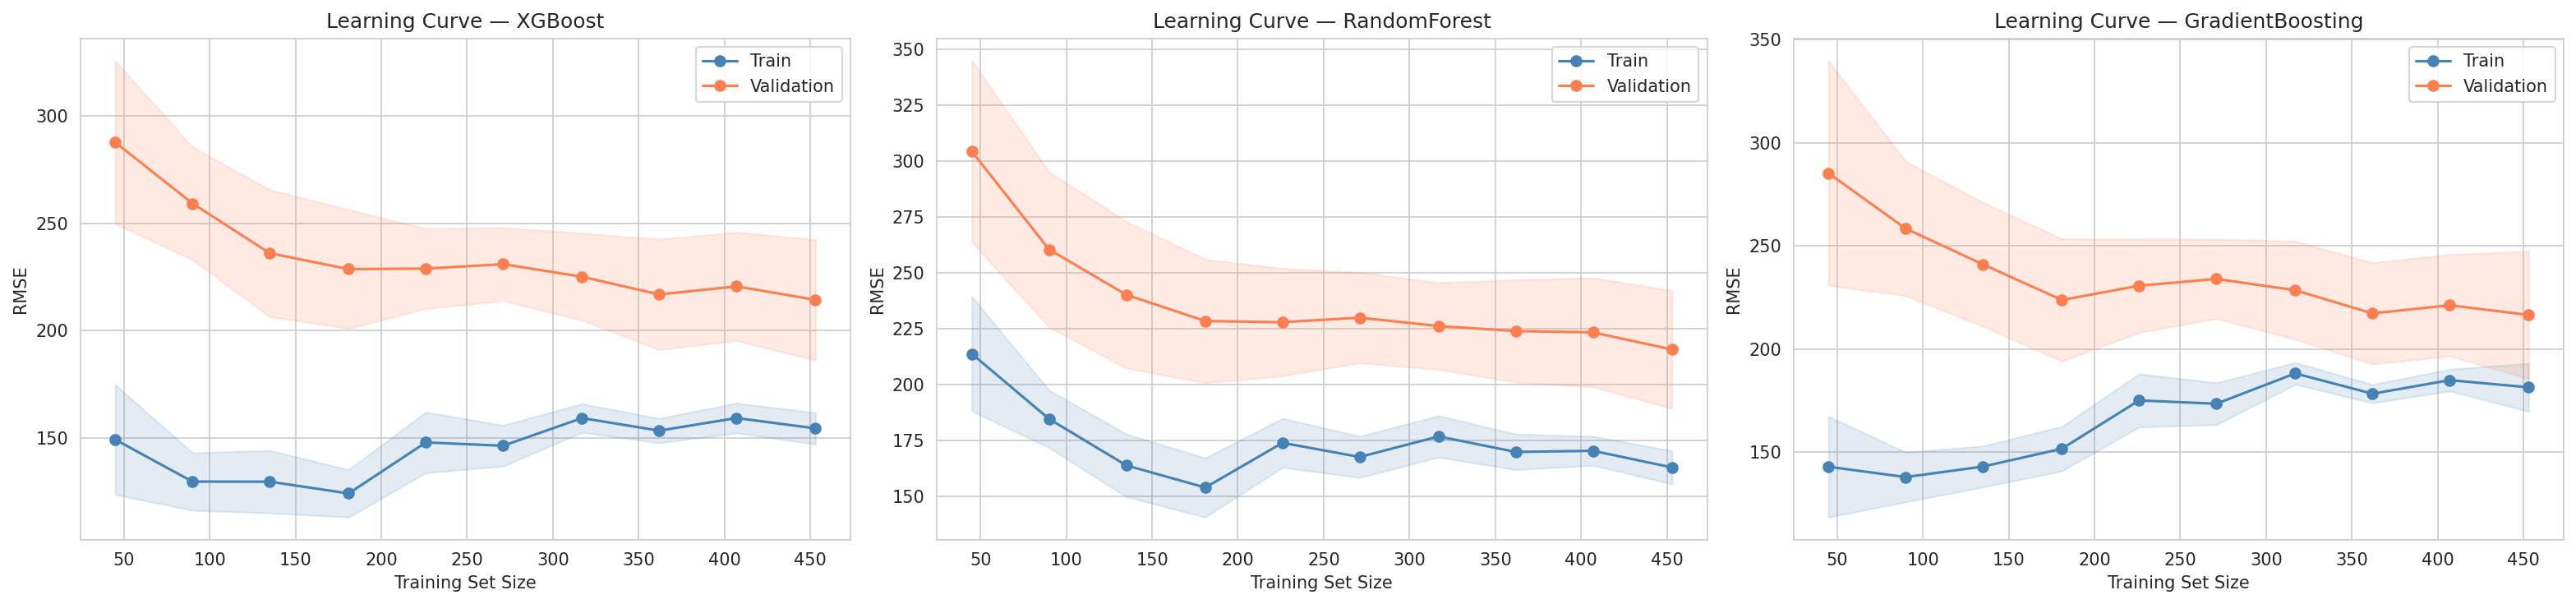

In [20]:
# ============================================================
# PLOT 4: LEARNING CURVES (Top 3 Models)
# ============================================================
fig, axes = plt.subplots(1, len(top3), figsize=(7 * len(top3), 5))
if len(top3) == 1: axes = [axes]

for ax, name in zip(axes, top3):
    pipe = best_estimators[name]
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X, y, train_sizes=np.linspace(0.1, 1.0, 10), cv=kf,
        scoring='neg_mean_squared_error', n_jobs=-1, random_state=RANDOM_STATE
    )
    train_rmse = np.sqrt(-train_scores)
    val_rmse = np.sqrt(-val_scores)

    ax.plot(train_sizes, train_rmse.mean(axis=1), 'o-', label='Train', color='steelblue')
    ax.fill_between(train_sizes, train_rmse.mean(axis=1) - train_rmse.std(axis=1),
                     train_rmse.mean(axis=1) + train_rmse.std(axis=1), alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_rmse.mean(axis=1), 'o-', label='Validation', color='coral')
    ax.fill_between(train_sizes, val_rmse.mean(axis=1) - val_rmse.std(axis=1),
                     val_rmse.mean(axis=1) + val_rmse.std(axis=1), alpha=0.15, color='coral')
    ax.set_xlabel('Training Set Size'); ax.set_ylabel('RMSE')
    ax.set_title(f'Learning Curve — {name}'); ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/04_learning_curves_top3.png', bbox_inches='tight', dpi=150)
plt.show()

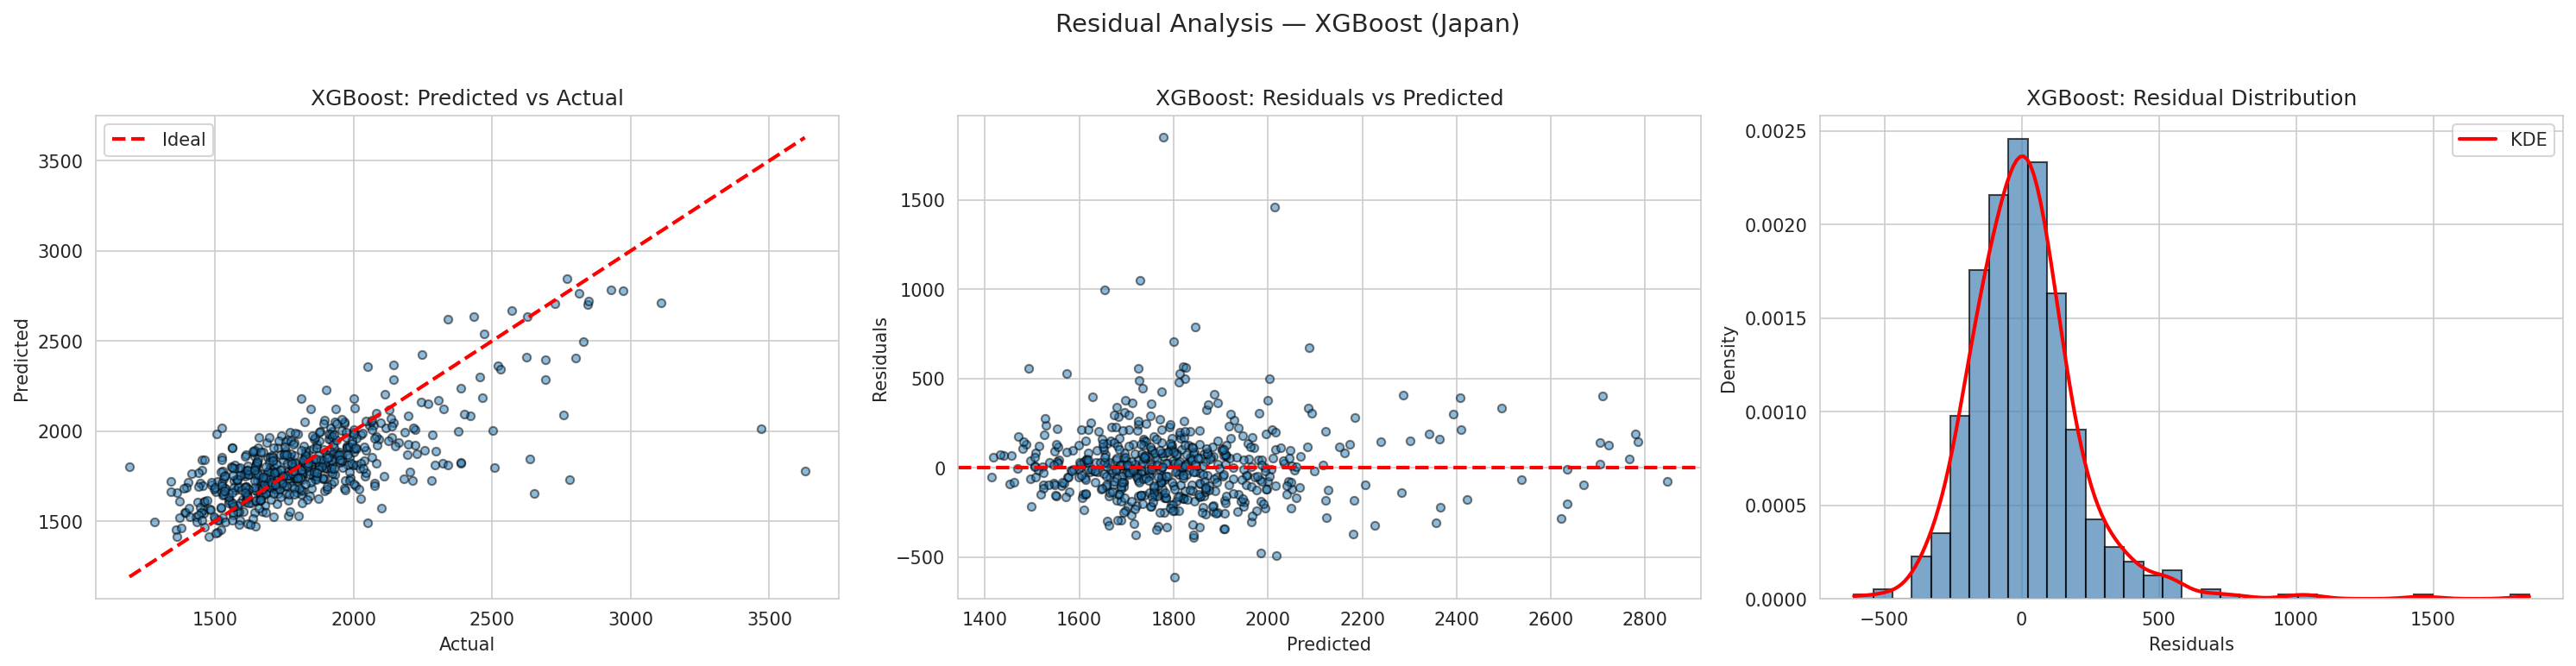

XGBoost — mean: 15.0943, std: 215.0913, skew: 2.283, kurtosis: 14.095


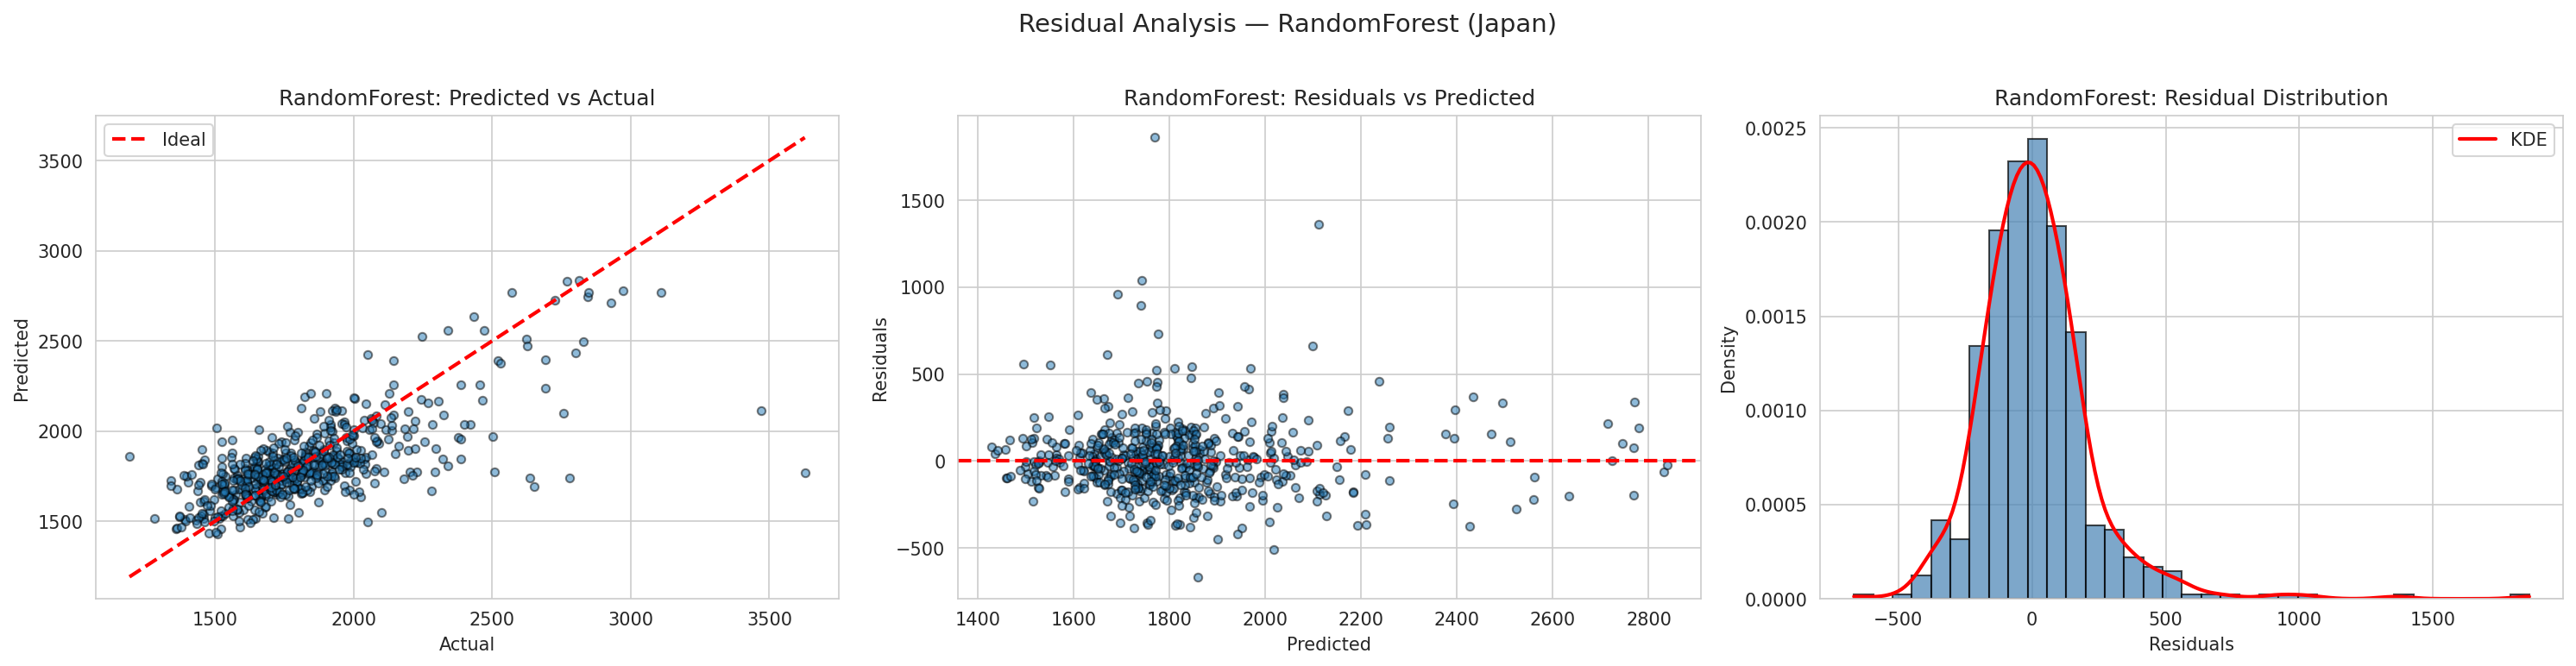

RandomForest — mean: 12.4447, std: 216.2747, skew: 2.166, kurtosis: 13.374


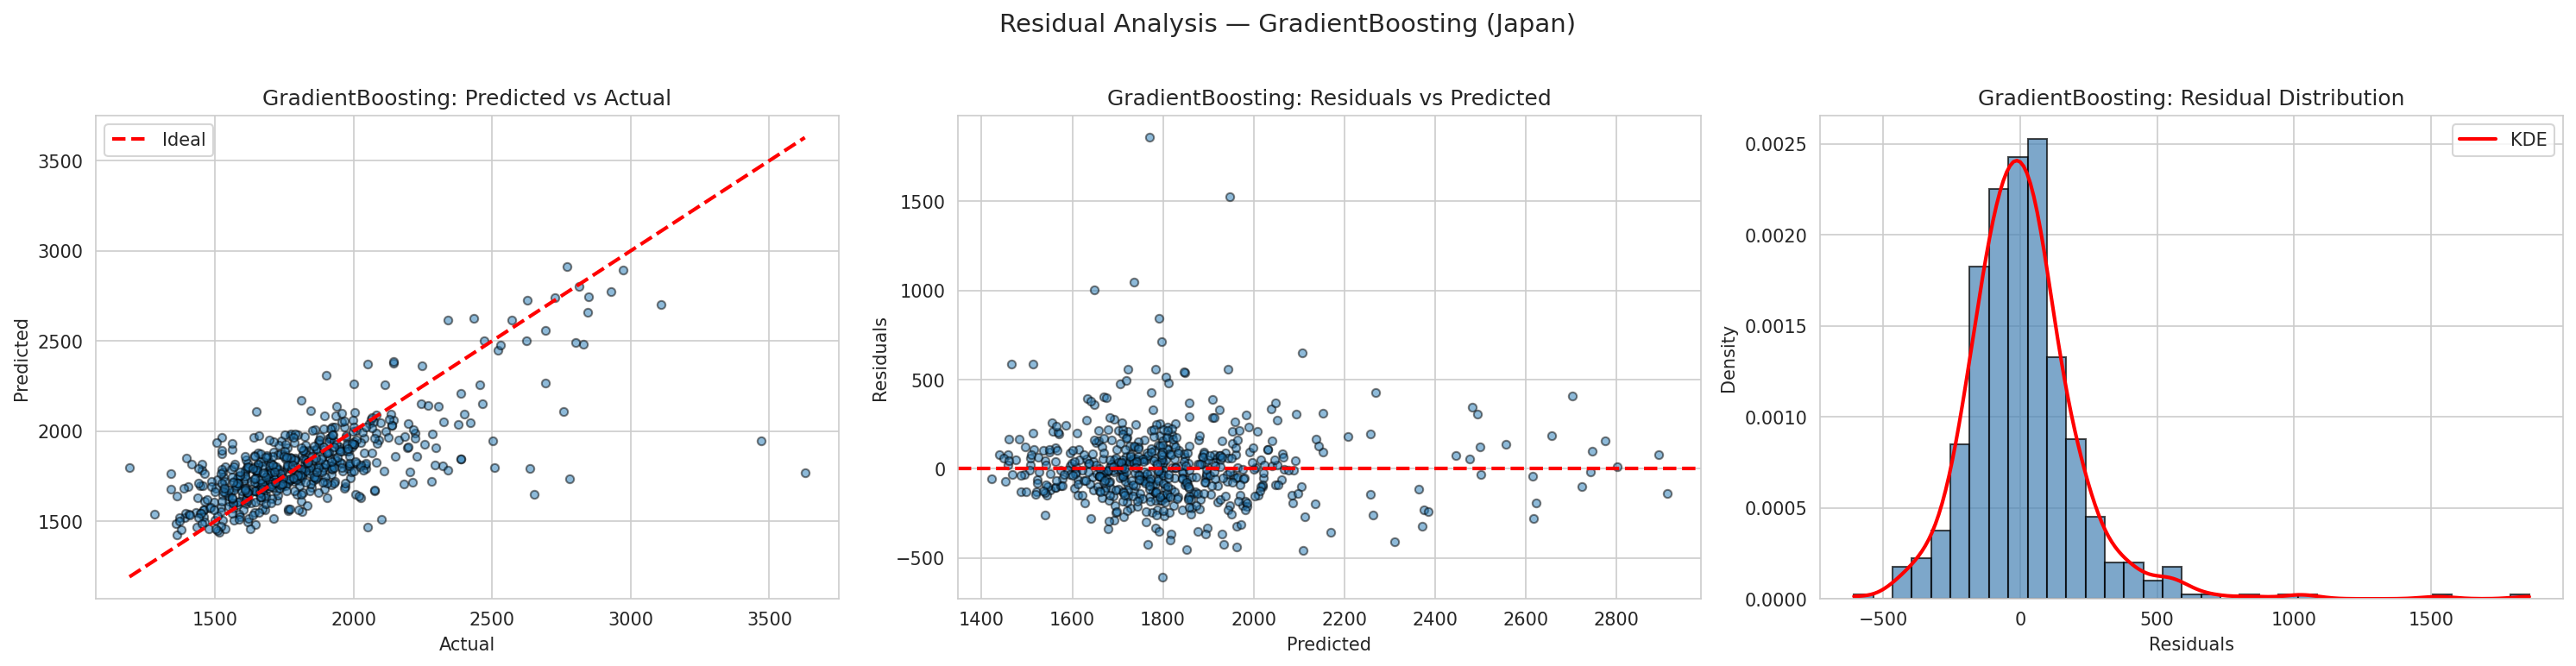

GradientBoosting — mean: 12.8364, std: 217.5122, skew: 2.332, kurtosis: 14.475


In [21]:
# ============================================================
# PLOT 5-7: RESIDUAL ANALYSIS (Top 3 Models)
# ============================================================
for name in top3:
    cv_preds = results[name]['CV_Preds']
    residuals = y - cv_preds

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Predicted vs Actual
    axes[0].scatter(y, cv_preds, alpha=0.5, edgecolors='black', s=20)
    min_val, max_val = min(y.min(), cv_preds.min()), max(y.max(), cv_preds.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal')
    axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
    axes[0].set_title(f'{name}: Predicted vs Actual'); axes[0].legend()

    # Residuals vs Predicted
    axes[1].scatter(cv_preds, residuals, alpha=0.5, edgecolors='black', s=20)
    axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'{name}: Residuals vs Predicted')

    # Residual distribution
    axes[2].hist(residuals, bins=35, edgecolor='black', alpha=0.7, color='steelblue', density=True)
    x_range = np.linspace(residuals.min(), residuals.max(), 200)
    kde = stats.gaussian_kde(residuals)
    axes[2].plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
    axes[2].set_xlabel('Residuals'); axes[2].set_ylabel('Density')
    axes[2].set_title(f'{name}: Residual Distribution'); axes[2].legend()

    plt.suptitle(f'Residual Analysis — {name} ({COUNTRY})', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/05_residual_analysis_{name}.png', bbox_inches='tight', dpi=150)
    plt.show()

    print(f"{name} — mean: {residuals.mean():.4f}, std: {residuals.std():.4f}, "
          f"skew: {residuals.skew():.3f}, kurtosis: {residuals.kurtosis():.3f}")

In [22]:
# ============================================================
# PLOT 8: FEATURE IMPORTANCE
# ============================================================
feature_names = preprocessor.get_feature_names_out()

tree_models_list = ['RandomForest', 'GradientBoosting', 'XGBoost']
linear_models_list = ['Ridge', 'Lasso', 'ElasticNet']

# Tree-based
tree_avail = [m for m in tree_models_list if m in best_estimators]
if tree_avail:
    fig, axes = plt.subplots(1, len(tree_avail), figsize=(6 * len(tree_avail), 8))
    if len(tree_avail) == 1: axes = [axes]
    for ax, name in zip(axes, tree_avail):
        imp = best_estimators[name].named_steps['model'].feature_importances_
        idx = np.argsort(imp)[-15:]
        ax.barh(range(len(idx)), imp[idx], color='steelblue', edgecolor='black')
        ax.set_yticks(range(len(idx)))
        ax.set_yticklabels([feature_names[i].split('__')[-1] for i in idx])
        ax.set_xlabel('Importance'); ax.set_title(name)
    plt.suptitle(f'Feature Importance — Tree Models ({COUNTRY})', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/08_feature_importance_tree.png', bbox_inches='tight', dpi=150)
    plt.show()

# Linear
linear_avail = [m for m in linear_models_list if m in best_estimators]
if linear_avail:
    fig, axes = plt.subplots(1, len(linear_avail), figsize=(6 * len(linear_avail), 8))
    if len(linear_avail) == 1: axes = [axes]
    for ax, name in zip(axes, linear_avail):
        coefs = np.abs(best_estimators[name].named_steps['model'].coef_)
        idx = np.argsort(coefs)[-15:]
        ax.barh(range(len(idx)), coefs[idx], color='coral', edgecolor='black')
        ax.set_yticks(range(len(idx)))
        ax.set_yticklabels([feature_names[i].split('__')[-1] for i in idx])
        ax.set_xlabel('|Coefficient|'); ax.set_title(name)
    plt.suptitle(f'Coefficient Magnitudes — Linear Models ({COUNTRY})', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/08_feature_importance_linear.png', bbox_inches='tight', dpi=150)
    plt.show()

NotFittedError: This ColumnTransformer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

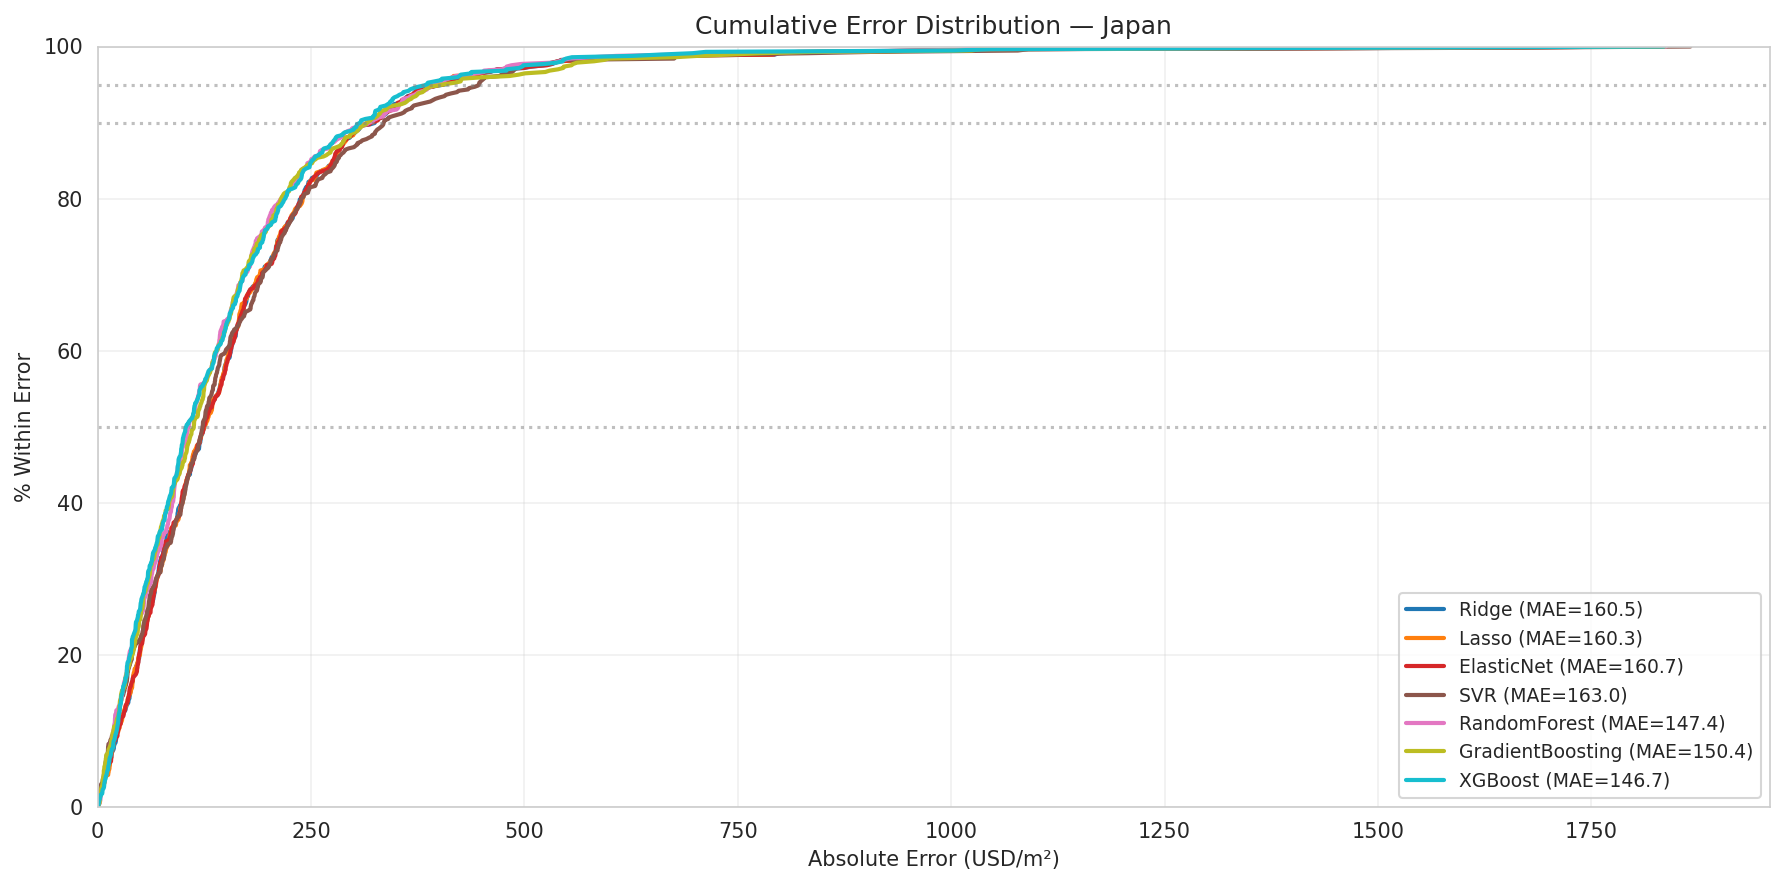

In [ ]:
# ============================================================
# PLOT 9: CUMULATIVE ERROR DISTRIBUTION
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, r), color in zip(results.items(), colors):
    abs_errors = np.abs(y - r['CV_Preds'])
    sorted_errors = np.sort(abs_errors)
    cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
    ax.plot(sorted_errors, cumulative, label=f"{name} (MAE={r['MAE']:.1f})", linewidth=2, color=color)

ax.set_xlabel('Absolute Error (USD/m²)'); ax.set_ylabel('% Within Error')
ax.set_title(f'Cumulative Error Distribution — {COUNTRY}')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(left=0); ax.set_ylim(0, 100)
for pct in [50, 90, 95]:
    ax.axhline(y=pct, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/09_cumulative_error_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

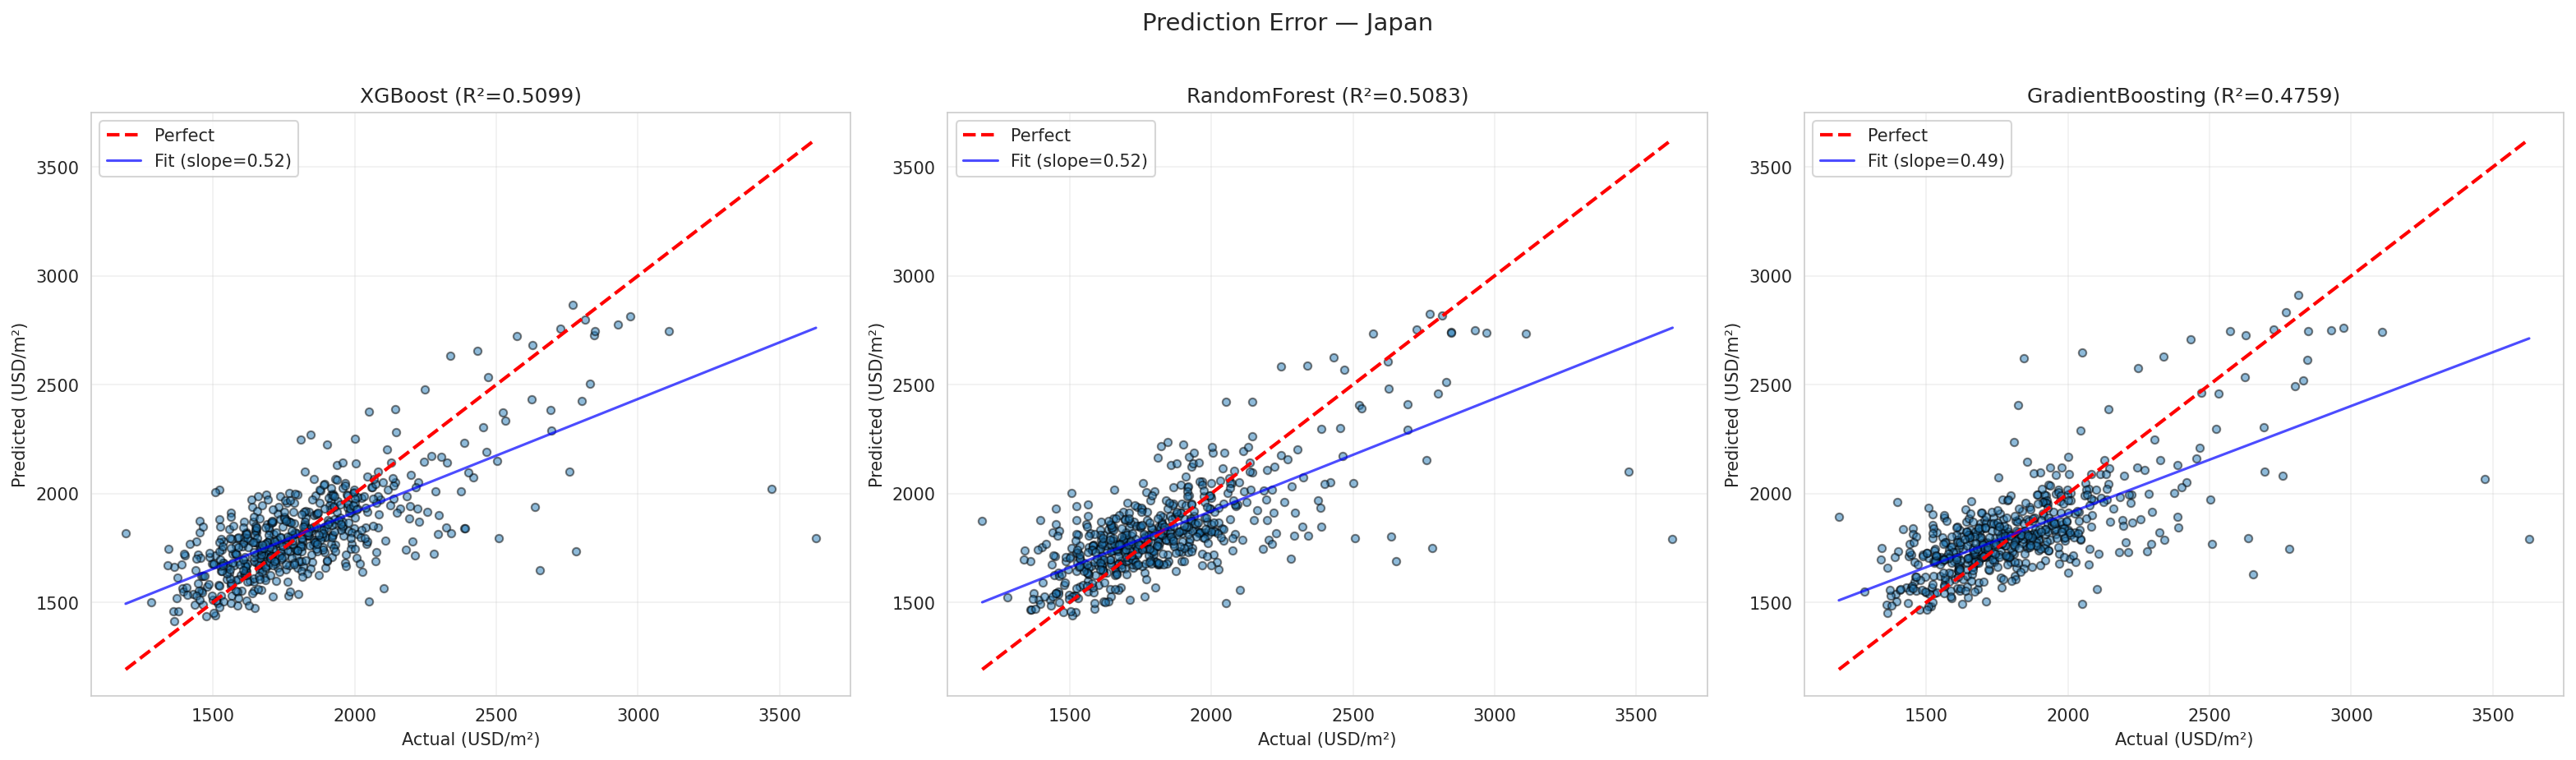

In [ ]:
# ============================================================
# PLOT 10: PREDICTION ERROR PLOT (Top 3)
# ============================================================
fig, axes = plt.subplots(1, len(top3), figsize=(7 * len(top3), 6))
if len(top3) == 1: axes = [axes]

for ax, name in zip(axes, top3):
    cv_preds = results[name]['CV_Preds']
    ax.scatter(y, cv_preds, alpha=0.5, edgecolors='black', s=20, zorder=3)
    min_val, max_val = min(y.min(), cv_preds.min()), max(y.max(), cv_preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect', zorder=4)
    z = np.polyfit(y, cv_preds, 1)
    p = np.poly1d(z)
    ax.plot(np.linspace(min_val, max_val, 100), p(np.linspace(min_val, max_val, 100)),
            'b-', linewidth=1.5, alpha=0.7, label=f'Fit (slope={z[0]:.2f})', zorder=4)
    ax.set_xlabel('Actual (USD/m²)'); ax.set_ylabel('Predicted (USD/m²)')
    ax.set_title(f'{name} (R²={results[name]["R2"]:.4f})'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Prediction Error — {COUNTRY}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/10_prediction_error_top3.png', bbox_inches='tight', dpi=150)
plt.show()

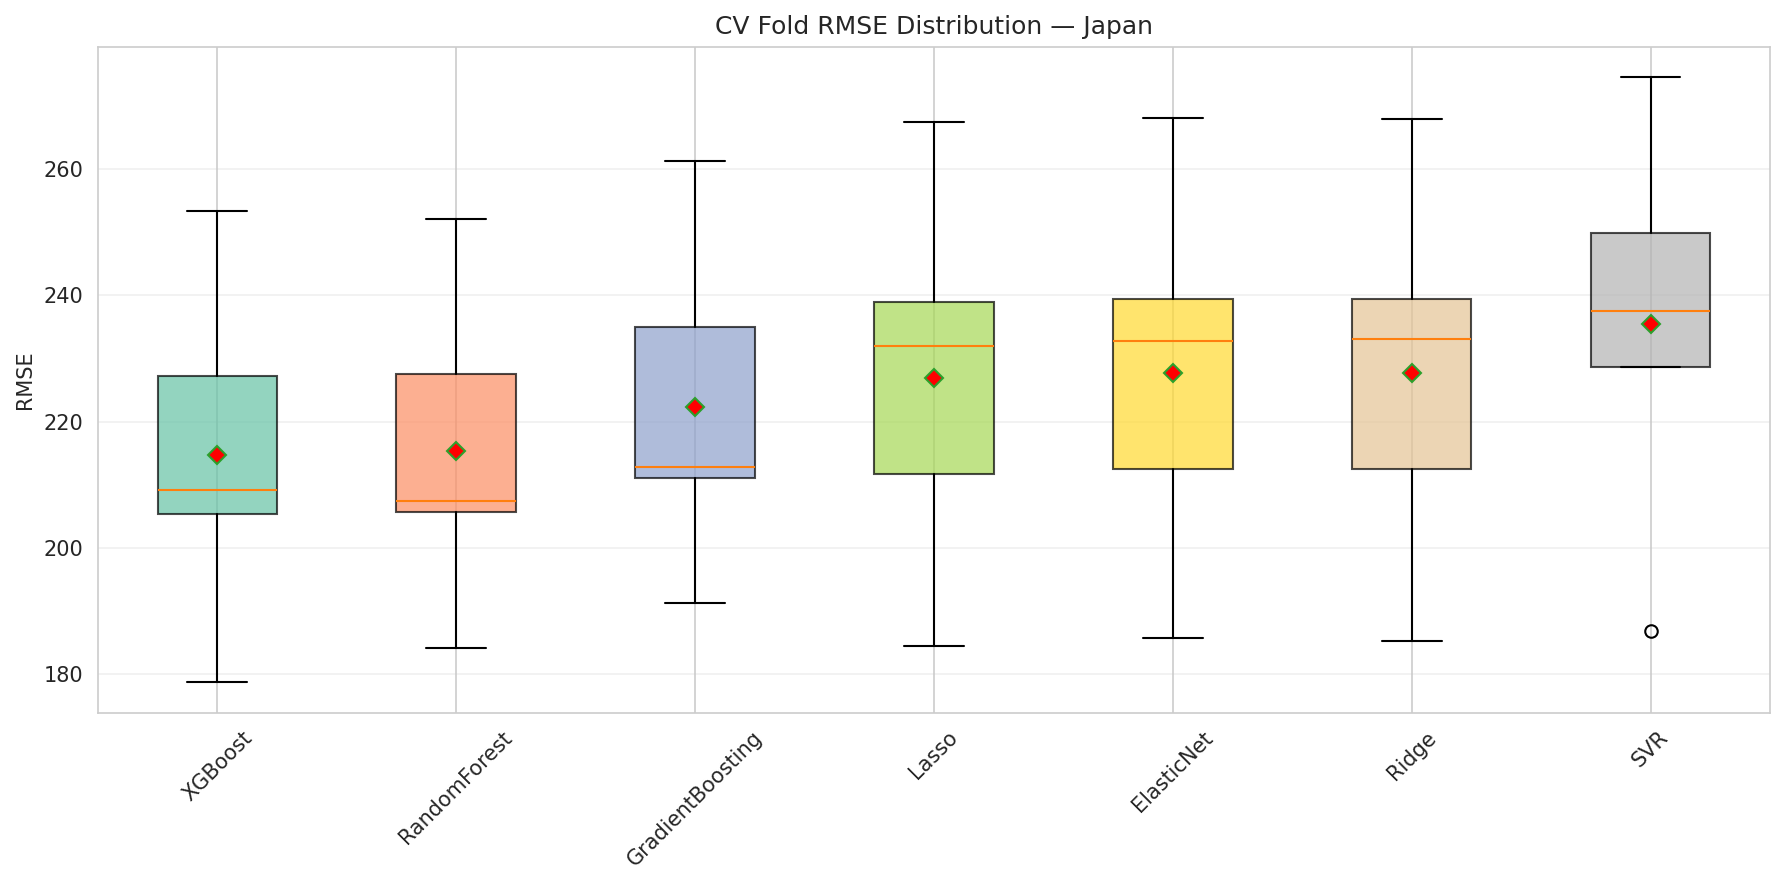

In [ ]:
# ============================================================
# PLOT 11: CV FOLD-WISE BOX PLOTS
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
fold_data = [results[name]['Fold_RMSEs'] for name in results_df.index]

bp = ax.boxplot(fold_data, labels=results_df.index.tolist(), patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=6))
colors = plt.cm.Set2(np.linspace(0, 1, len(fold_data)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)

ax.set_ylabel('RMSE'); ax.set_title(f'CV Fold RMSE Distribution — {COUNTRY}')
ax.tick_params(axis='x', rotation=45); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/11_cv_fold_scores_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

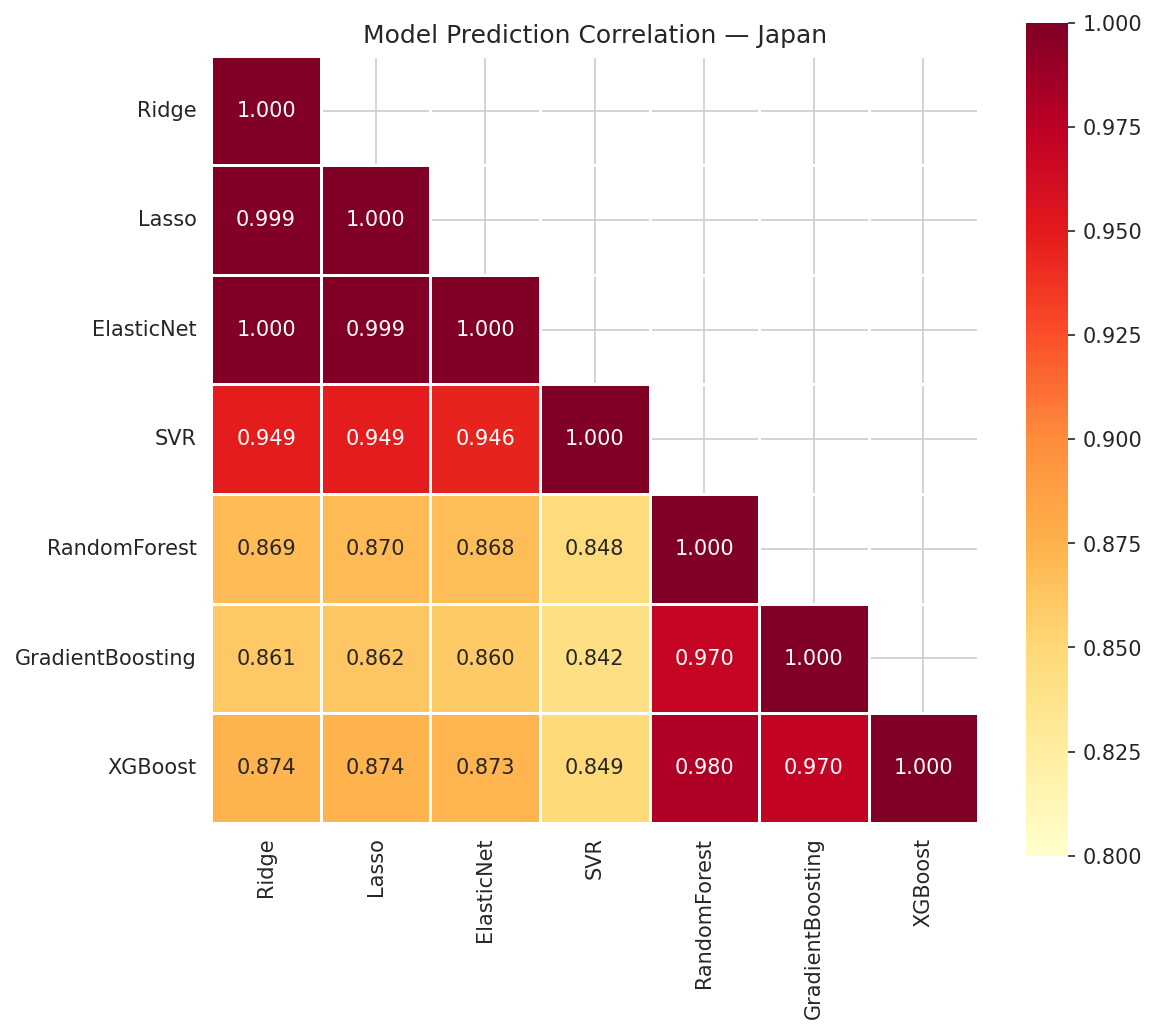

💡 Models with LOW correlation are good ensemble candidates.


In [ ]:
# ============================================================
# PLOT 12: MODEL PREDICTION CORRELATION
# ============================================================
pred_df = pd.DataFrame({name: results[name]['CV_Preds'] for name in results})
pred_corr = pred_df.corr()

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(pred_corr, dtype=bool), k=1)
sns.heatmap(pred_corr, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            mask=mask, square=True, linewidths=0.5, vmin=0.8, vmax=1.0)
ax.set_title(f'Model Prediction Correlation — {COUNTRY}')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/12_model_prediction_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

print("💡 Models with LOW correlation are good ensemble candidates.")

## Phase 5: Model Persistence & Reusability

In [ ]:
# ============================================================
# SAVE ALL TRAINED MODELS & RESULTS
# ============================================================
print(f"Saving all models to {MODELS_DIR}/ ...\n")

for name, estimator in best_estimators.items():
    filepath = f'{MODELS_DIR}/{name}.joblib'
    joblib.dump(estimator, filepath)
    size_mb = os.path.getsize(filepath) / (1024 * 1024)
    print(f"   ✅ {filepath} ({size_mb:.1f} MB)")

# Save results summary
results_export = results_df.copy()
results_export['Best_Params'] = [
    str({k.replace('model__', ''): v for k, v in results[name]['Best_Params'].items()})
    for name in results_export.index
]
results_export.to_csv(f'{MODELS_DIR}/results_summary.csv')
print(f"\n   ✅ {MODELS_DIR}/results_summary.csv")

best_model_name = results_df.index[0]
with open(f'{MODELS_DIR}/best_model.txt', 'w') as f:
    f.write(best_model_name)
print(f"\n🏆 Best model: {best_model_name} (RMSE={results_df.loc[best_model_name, 'RMSE']:.4f})")
print(f"\n📁 All files saved to {MODELS_DIR}/")
print(f"📊 All plots saved to {PLOTS_DIR}/")

Saving all models to saved_models_japan/ ...

   ✅ saved_models_japan/Ridge.joblib (0.0 MB)
   ✅ saved_models_japan/Lasso.joblib (0.0 MB)
   ✅ saved_models_japan/ElasticNet.joblib (0.0 MB)
   ✅ saved_models_japan/SVR.joblib (0.1 MB)
   ✅ saved_models_japan/RandomForest.joblib (8.7 MB)
   ✅ saved_models_japan/GradientBoosting.joblib (3.1 MB)
   ✅ saved_models_japan/XGBoost.joblib (1.8 MB)

   ✅ saved_models_japan/results_summary.csv

🏆 Best model: XGBoost (RMSE=216.2001)

📁 All files saved to saved_models_japan/
📊 All plots saved to plots_japan/


In [ ]:
# ============================================================
# UTILITY: LOAD A SAVED MODEL & PREDICT ON NEW DATA
# ============================================================
# STANDALONE — restart kernel and run only this cell. No retraining needed!

import pandas as pd
import numpy as np
import joblib
import os

COUNTRY = 'Japan'
MODELS_DIR = 'saved_models_japan'
MODEL_NAME = 'best'  # Or: 'Ridge', 'XGBoost', 'RandomForest', etc.

# Load model
if MODEL_NAME == 'best':
    with open(f'{MODELS_DIR}/best_model.txt', 'r') as f:
        MODEL_NAME = f.read().strip()
    print(f"Auto-loading best model: {MODEL_NAME}")

pipeline = joblib.load(f'{MODELS_DIR}/{MODEL_NAME}.joblib')
print(f"✅ Loaded: {MODELS_DIR}/{MODEL_NAME}.joblib")

# Load results
results_summary = pd.read_csv(f'{MODELS_DIR}/results_summary.csv', index_col=0)
print(f"\n📊 Model performance:")
print(results_summary.loc[[MODEL_NAME], ['RMSE', 'MAE', 'R²']])

# Predict on evaluation set (filtered to Japan)
eval_df = pd.read_csv('evaluation_tabular_no_target.csv')
eval_ids = eval_df[eval_df['country'] == COUNTRY]['data_id'].values
eval_df = eval_df[eval_df['country'] == COUNTRY].copy()

DROP_COLS = ['data_id', 'sentinel2_tiff_file_name', 'viirs_tiff_file_name',
             'country', 'developed_country', 'region_economic_classification', 'landlocked']
eval_df = eval_df.drop(columns=DROP_COLS)

# Check & drop near-constant columns (same as training)
for col in eval_df.columns:
    if eval_df[col].nunique() <= 1 and col != 'construction_cost_per_m2_usd':
        eval_df = eval_df.drop(columns=[col])

eval_df['quarter'] = eval_df['quarter_label'].str.extract(r'Q(\d)').astype(int)
eval_df = eval_df.drop(columns=['quarter_label'])

predictions = pipeline.predict(eval_df)

print(f"\n🔮 Predictions ({COUNTRY}): {len(predictions)} rows")
print(f"   Min: {predictions.min():.2f} | Max: {predictions.max():.2f} | Mean: {predictions.mean():.2f}")

pred_df = pd.DataFrame({'data_id': eval_ids, 'construction_cost_per_m2_usd': predictions})
pred_df.to_csv(f'predictions_japan_{MODEL_NAME}.csv', index=False)
print(f"\n💾 Saved: predictions_japan_{MODEL_NAME}.csv")
pred_df.head(10)

Auto-loading best model: XGBoost
✅ Loaded: saved_models_japan/XGBoost.joblib

📊 Model performance:
               RMSE         MAE        R²
Model                                    
XGBoost  216.200061  146.673449  0.509931

🔮 Predictions (Japan): 561 rows
   Min: 1422.59 | Max: 2874.29 | Mean: 1807.66

💾 Saved: predictions_japan_XGBoost.csv


,data_id,construction_cost_per_m2_usd
0,3TOW4,1864.534424
1,493WX,1662.529663
2,UYP04,1778.669922
3,CPRHV,1735.318481
4,74RS7,1667.297729
5,JIPNF,2029.294189
6,IA5U6,1729.100708
7,EH5SW,1655.361816
8,ANJ4X,1780.623169
9,LA100,1823.592285


In [ ]:
# ============================================================
# SUMMARY: ALL SAVED ARTIFACTS
# ============================================================
print(f"📁 SAVED MODELS ({MODELS_DIR}/):")
for f in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(f'{MODELS_DIR}/{f}') / (1024 * 1024)
    print(f"   {MODELS_DIR}/{f} ({size:.1f} MB)")

print(f"\n📊 SAVED PLOTS ({PLOTS_DIR}/):")
for f in sorted(os.listdir(PLOTS_DIR)):
    size = os.path.getsize(f'{PLOTS_DIR}/{f}') / 1024
    print(f"   {PLOTS_DIR}/{f} ({size:.0f} KB)")

print(f"\n✅ Total: {len(os.listdir(MODELS_DIR))} model files, {len(os.listdir(PLOTS_DIR))} plots")

📁 SAVED MODELS (saved_models_japan/):
   saved_models_japan/ElasticNet.joblib (0.0 MB)
   saved_models_japan/GradientBoosting.joblib (3.1 MB)
   saved_models_japan/Lasso.joblib (0.0 MB)
   saved_models_japan/RandomForest.joblib (8.7 MB)
   saved_models_japan/Ridge.joblib (0.0 MB)
   saved_models_japan/SVR.joblib (0.1 MB)
   saved_models_japan/XGBoost.joblib (1.8 MB)
   saved_models_japan/best_model.txt (0.0 MB)
   saved_models_japan/results_summary.csv (0.0 MB)

📊 SAVED PLOTS (plots_japan/):
   plots_japan/01_model_comparison_metrics.png (69 KB)
   plots_japan/02_hyperparam_ElasticNet.png (74 KB)
   plots_japan/02_hyperparam_GradientBoosting.png (116 KB)
   plots_japan/02_hyperparam_Lasso.png (41 KB)
   plots_japan/02_hyperparam_RandomForest.png (120 KB)
   plots_japan/02_hyperparam_Ridge.png (44 KB)
   plots_japan/02_hyperparam_SVR.png (77 KB)
   plots_japan/02_hyperparam_XGBoost.png (126 KB)
   plots_japan/03_validation_curves_top3.png (185 KB)
   plots_japan/04_learning_curves_top3.